# 🏨 StayPredict
## AI-Powered Hotel Revenue and Cancellation Management System

**Layihənin məqsədi:** Otel rəhbərliyinə hansı rezervasiyaların ləğv olunacağını əvvəlcədən proqnozlaşdırmaqda, potensial gəlir itkisini hesablamaqda və riskli rezervasiyalar üçün konkret tədbirlər təklif etməkdə köməkçi olmaq.

---

### Məzmun

| Mərhələ | Başlıq |
|---|---|
| 1 | Business Understanding |
| 2 | Data Loading |
| 3 | Data Cleaning |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Feature Engineering |
| 6 | Feature Selection |
| 7 | Train / Test Split |
| 8 | Preprocessing Pipeline |
| 9 | Baseline Modellər |
| 10 | Model Comparison |
| 11 | Qalib Model |
| 12 | Hyperparameter Tuning |
| 13 | Cross Validation |
| 14 | Threshold Optimization |
| 15 | Explainable AI (SHAP) + 🤖 AI Risk Assistant (bonus) |
| 16 | Revenue Analytics |
| 17 | What-If Simulator |
| 18 | Recommendation Engine |
| 19 | Time Series Forecasting & Overbooking Simulation |
| 20 | Dashboard (Streamlit) haqqında qeyd |


## 0. Mühitin Qurulması


In [ ]:
# Lazımi kitabxanaları quraşdırırıq
!pip install -q xgboost shap ipywidgets plotly

print("Bütün kitabxanalar uğurla quraşdırıldı.")

Bütün kitabxanalar uğurla quraşdırıldı.


In [ ]:
# ---- Əsas kitabxanalar ----
import pandas as pd                      # Cədvəl (DataFrame) formatında data ilə işləmək üçün
import numpy as np                       # Riyazi və array əməliyyatları üçün

# ---- Vizualizasiya kitabxanaları ----
import matplotlib.pyplot as plt          # Əsas qrafik çəkmə kitabxanası
import seaborn as sns                    # Matplotlib üzərində qurulmuş, daha estetik statistik qrafiklər
import plotly
import plotly.express as px              # İnteraktiv qrafiklər (dashboard hissəsi üçün faydalıdır)

# ---- Machine Learning kitabxanaları (scikit-learn) ----
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer          # Fərqli sütun tiplərinə fərqli preprocessing tətbiq etmək üçün
from sklearn.pipeline import Pipeline                    # Bütün addımları (preprocessing + model) bir zəncirə bağlamaq üçün
from sklearn.impute import SimpleImputer                 # Boş (missing) dəyərləri doldurmaq üçün
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Say. dəyişənləri miqyaslamaq, kateqorik dəyişənləri kodlaşdırmaq
from sklearn.linear_model import LogisticRegression       # Baseline model 1
from sklearn.ensemble import RandomForestClassifier        # Baseline model 2
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, precision_recall_curve, classification_report)

# ---- Boosting modeli ----
import xgboost as xgb                    # Güclü gradient boosting modeli (Baseline model 3)

# ---- Explainable AI ----
import shap                              # Modelin qərarlarını izah etmək üçün (Explainable AI)

# ---- Digər ----
import warnings
warnings.filterwarnings("ignore")        # Xəbərdarlıqları (warning) gizlədirik ki, çıxış (output) təmiz görünsün

# ---- Vizual tənzimləmələr ----
sns.set_style("whitegrid")               # Bütün seaborn qrafikləri üçün ağ, xətli fon
plt.rcParams["figure.figsize"] = (10, 6) # Standart qrafik ölçüsü
pd.set_option("display.max_columns", 40) # Bütün sütunları göstər (kəsilməsin)

print("Bütün kitabxanalar import olundu və mühit hazırdır.")

Bütün kitabxanalar import olundu və mühit hazırdır.


---
## 1 — Business Understanding

### Əsas Suallar

1. **Hansı rezervasiyalar ləğv olacaq?**  
2. **Bu ləğvlər nə qədər gəlir itkisi yaradacaq?**
3. **Riski azaltmaq üçün nə etmək olar?**

### Niyə vacibdir?

Otel sənayesində rezervasiya ləğvləri gəlirin böyük hissəsini itirməyə səbəb olur. Əgər otel hansı rezervasiyaların riskli olduğunu əvvəlcədən bilsə:
- Otaqları overbooking strategiyası ilə daha səmərəli idarə edə bilər,
- Riskli müştərilərdən qabaqcadan depozit tələb edə bilər,
- Marketinq resurslarını "at-risk" qonaqlara yönəldə bilər.

### Uğur Meyarları (Success Metrics)

| Meyar | Məqsəd |
|---|---|
| Recall | Yüksək olmalı — ləğv ediləcək rezervasiyanı buraxmamaq vacibdir |
| ROC-AUC | Modelin ümumi ayırdetmə gücünü göstərir |
| Business Impact | Neçə manat gəlirin qorunduğunu göstərməlidir |


---
## 2 — Data Loading

### `Hotel Booking` datasetini yükləyib ilkin tanışlıq aparırıq.

In [ ]:
# CSV faylını Pandas DataFrame-ə oxuyuruq
df = pd.read_csv("hotel_bookings.csv")

# DataFrame-in ilk 5 sətrinə baxırıq ki, sütunların necə göründüyünü görək
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [ ]:
# Dataset-in ölçüsünü yoxlayırıq
print(f"Sətir sayı (rezervasiya sayı): {df.shape[0]}")
print(f"Sütun sayı (dəyişən sayı):    {df.shape[1]}")

Sətir sayı (rezervasiya sayı): 119390
Sütun sayı (dəyişən sayı):    32


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# describe() metodu yalnız ədədi (numeric) sütunlar üçün statistik xülasə verir:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [ ]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [ ]:
# Kateqorik (mətn tipli) sütunlar üçün də qısa statistika görək
df.describe(include = "object").T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


---
## 3 — Data Cleaning

Datamızı təmizləyirik: boş dəyərləri (missing values) idarə edirik, dublikatları siləcəyik və data tiplərini düzəldəcəyik.

In [ ]:
# Hər sütunda neçə boş (NaN) dəyər olduğunu hesablayırıq
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

# Yalnız boş dəyəri olan sütunları göstəririk, faizə görə sıralayırıq
missing_df = pd.DataFrame({"Boş dəyər sayı": missing, "Faiz (%)": missing_percent})
missing_df = missing_df[missing_df["Boş dəyər sayı"] > 0].sort_values("Faiz (%)", ascending=False)
missing_df

,Boş dəyər sayı,Faiz (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [ ]:
# 'company' sütununda boş dəyərlərin faizi çox yüksəkdir (~94%) —
# bu o deməkdir ki, əksər müştərilər şirkət adı ilə rezervasiya etməyib.
# Bu sütunu tam silmək əvəzinə, boş dəyərləri 0 (şirkət ID-si yoxdur) ilə əvəz edirik,
# çünki NULL burada 'informasiya yoxdur' deyil, 'şirkət yoxdur' mənasını daşıyır.
df["company"] = df["company"].fillna(0)

# 'agent' sütunu da bənzər məntiqlə doldurulur — 0, 'agent vasitəsilə olmayıb' deməkdir
df["agent"] = df["agent"].fillna(0)

# 'country' sütununda boş dəyərlər ən çox rast gəlinən ölkə (mode) ilə doldurulur
df["country"] = df["country"].fillna(df["country"].mode()[0])

# 'children' sütunundakı bir neçə boş dəyəri 0 ilə əvəz edirik (uşaq sayı məlum olmayanda, ehtimal ki, uşaq yoxdur)
df["children"] = df["children"].fillna(0)

print("✅ Boş dəyərlər uğurla dolduruldu.")
print(f"Qalan boş dəyər sayı: {df.isnull().sum().sum()}")

✅ Boş dəyərlər uğurla dolduruldu.
Qalan boş dəyər sayı: 0


In [ ]:
# Dublikat (təkrarlanan) sətirlərin sayını yoxlayırıq
duplicate_count = df.duplicated().sum()
print(f"Tapılan dublikat sətir sayı: {duplicate_count}")

# Dublikatları silirik və indeksi yenidən sıralayırıq (reset_index)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dublikatlar silindikdən sonra sətir sayı: {df.shape[0]}")

Tapılan dublikat sətir sayı: 32013
Dublikatlar silindikdən sonra sətir sayı: 87377


In [ ]:
# 'reservation_status_date' sütunu hazırda mətn (string) formatındadır — onu tarix (datetime) formatına çeviririk
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

# 'children', 'agent', 'company' sütunları float tipində idi (çünki NaN daşıyırdı) — indi tam ədədə (int) çeviririk
df["children"] = df["children"].astype(int)
df["agent"] = df["agent"].astype(int)
df["company"] = df["company"].astype(int)

# Yoxlayırıq ki, dəyişikliklər düzgün tətbiq olunub
df.dtypes[["reservation_status_date", "children", "agent", "company"]]

,0
reservation_status_date,datetime64[ns]
children,int64
agent,int64
company,int64


In [ ]:
# Məntiqsiz sətirləri təmizləyirik: adults=0 VƏ children=0 VƏ babies=0 olan sətirlər —
# yəni heç bir qonağı olmayan "rezervasiyalar". Bunlar data xətasıdır.
guests_zero = (df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)
print(f"Qonaqsız (səhv) sətir sayı: {guests_zero.sum()}")

df = df[~guests_zero].reset_index(drop=True)
print(f"Təmizləndikdən sonra son sətir sayı: {df.shape[0]}")

Qonaqsız (səhv) sətir sayı: 166
Təmizləndikdən sonra son sətir sayı: 87211


---
## 4 — Exploratory Data Analysis (EDA)

Datamızı vizual olaraq araşdırırıq ki, dəyişənlər arasındakı əlaqələri, paylanmaları və trendləri başa düşək.

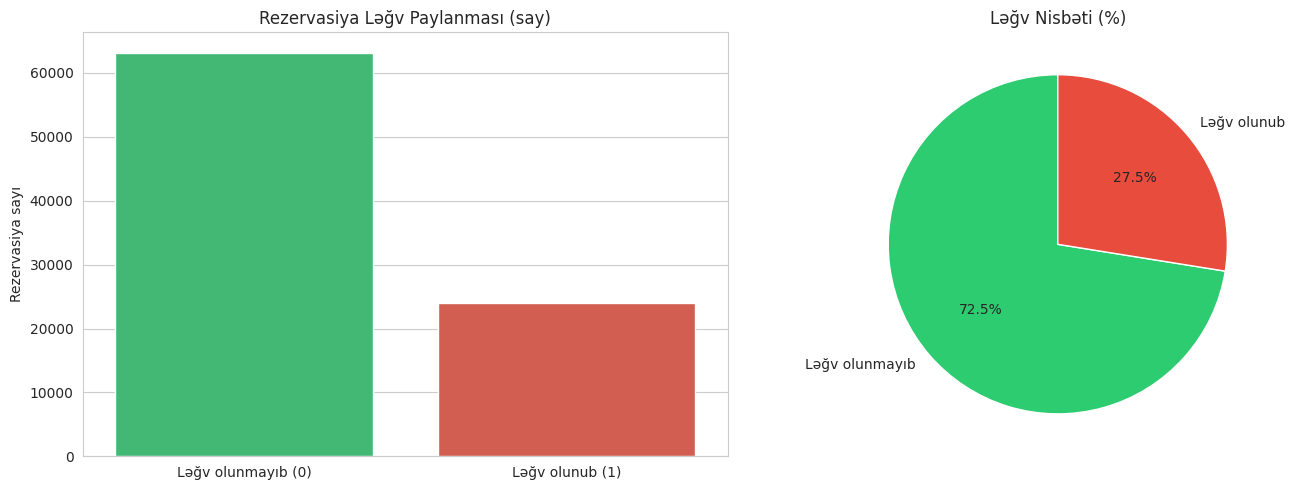

📊 Ümumi ləğv nisbəti: 27.53%


In [ ]:
# --- 4.1 Cancellation Distribution (Ləğv Paylanması) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Sol qrafik: bar chart — neçə rezervasiya ləğv olub, neçəsi olmayıb
sns.countplot(data=df, x="is_canceled", palette=["#2ecc71", "#e74c3c"], ax=ax[0])
ax[0].set_xticklabels(["Ləğv olunmayıb (0)", "Ləğv olunub (1)"])
ax[0].set_title("Rezervasiya Ləğv Paylanması (say)")
ax[0].set_xlabel("")
ax[0].set_ylabel("Rezervasiya sayı")

# Sağ qrafik: pie chart — faiz nisbəti
cancel_counts = df["is_canceled"].value_counts()
ax[1].pie(cancel_counts, labels=["Ləğv olunmayıb", "Ləğv olunub"], autopct="%1.1f%%",
          colors=["#2ecc71", "#e74c3c"], startangle=90)
ax[1].set_title("Ləğv Nisbəti (%)")

plt.tight_layout()
plt.show()

cancellation_rate = df["is_canceled"].mean() * 100
print(f"📊 Ümumi ləğv nisbəti: {cancellation_rate:.2f}%")

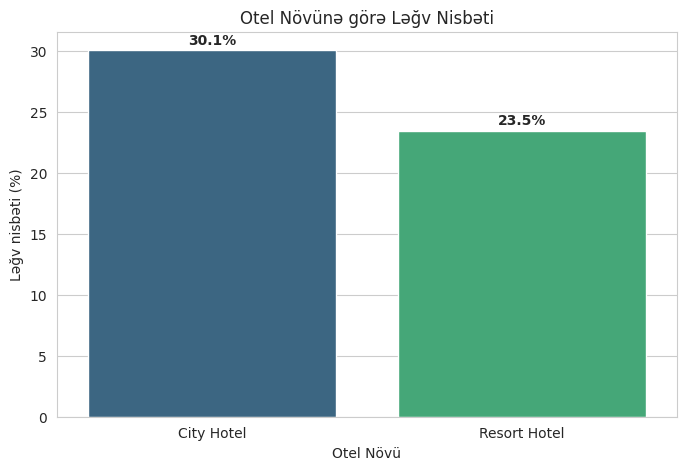

In [ ]:
# --- 4.2 Hotel Type üzrə Ləğv Nisbəti ---
plt.figure(figsize=(8, 5))
hotel_cancel = df.groupby("hotel")["is_canceled"].mean() * 100
sns.barplot(x=hotel_cancel.index, y=hotel_cancel.values, palette="viridis")
plt.title("Otel Növünə görə Ləğv Nisbəti")
plt.ylabel("Ləğv nisbəti (%)")
plt.xlabel("Otel Növü")
for i, v in enumerate(hotel_cancel.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.show()

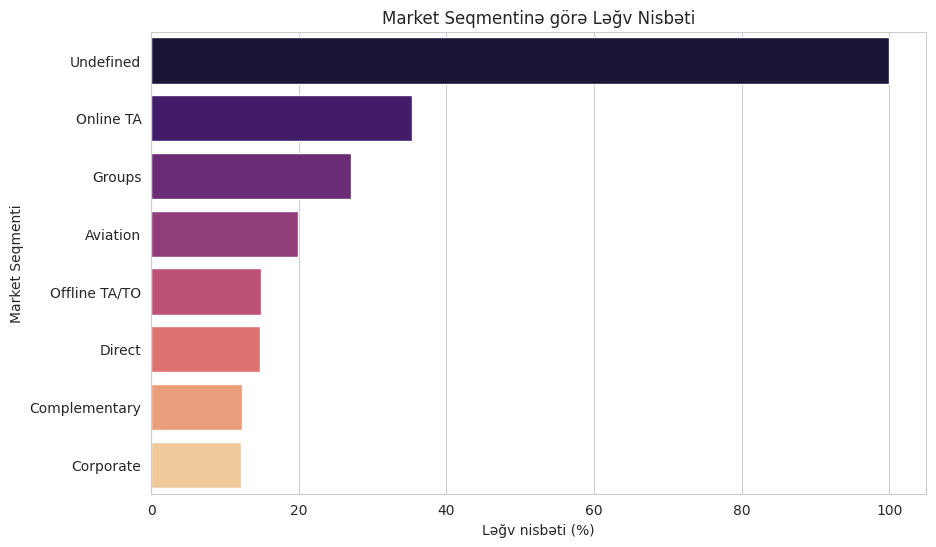

In [ ]:
# --- 4.3 Market Segment üzrə Ləğv Nisbəti ---
plt.figure(figsize=(10, 6))
segment_cancel = df.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False) * 100
sns.barplot(x=segment_cancel.values, y=segment_cancel.index, palette="magma")
plt.title("Market Seqmentinə görə Ləğv Nisbəti")
plt.xlabel("Ləğv nisbəti (%)")
plt.ylabel("Market Seqmenti")
plt.show()

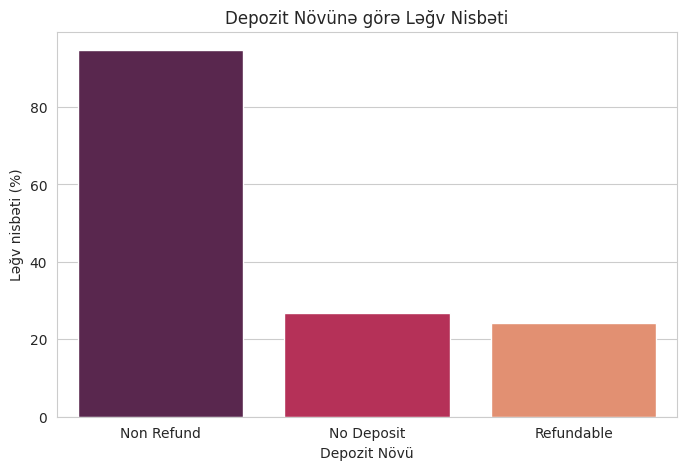

In [ ]:
# --- 4.4 Deposit Type üzrə Ləğv Nisbəti ---
plt.figure(figsize=(8, 5))
deposit_cancel = df.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False) * 100
sns.barplot(x=deposit_cancel.index, y=deposit_cancel.values, palette="rocket")
plt.title("Depozit Növünə görə Ləğv Nisbəti")
plt.ylabel("Ləğv nisbəti (%)")
plt.xlabel("Depozit Növü")
plt.show()

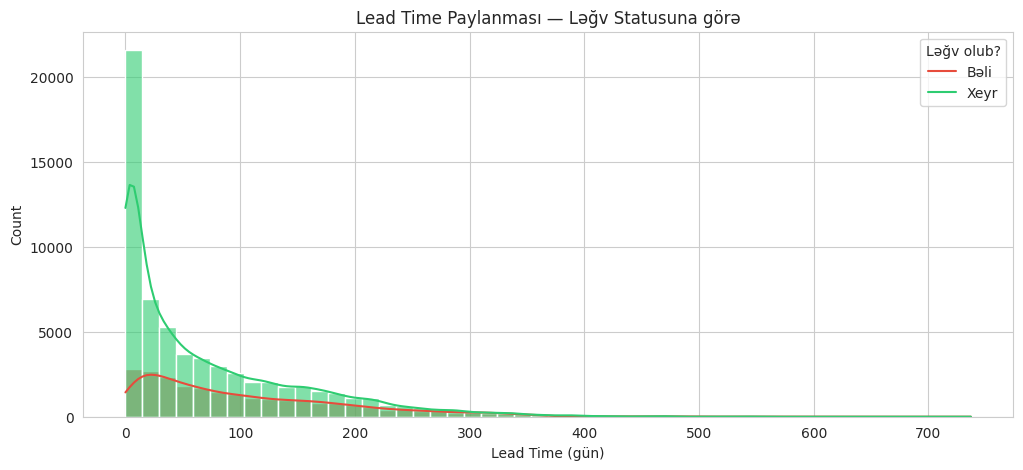

 Müşahidə: Lead time nə qədər uzun olarsa, ləğv ehtimalı bir o qədər artır — çünki uzun müddət ərzində müştərinin planları dəyişə bilər.


In [ ]:
# --- 4.5 Lead Time (Rezervasiya ilə giriş arası müddət) Paylanması ---
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="lead_time", hue="is_canceled", bins=50, kde=True,
             palette={0: "#2ecc71", 1: "#e74c3c"}, alpha=0.6)
plt.title("Lead Time Paylanması — Ləğv Statusuna görə")
plt.xlabel("Lead Time (gün)")
plt.legend(title="Ləğv olub?", labels=["Bəli", "Xeyr"])
plt.show()

print(" Müşahidə: Lead time nə qədər uzun olarsa, ləğv ehtimalı bir o qədər artır — "
      "çünki uzun müddət ərzində müştərinin planları dəyişə bilər.")

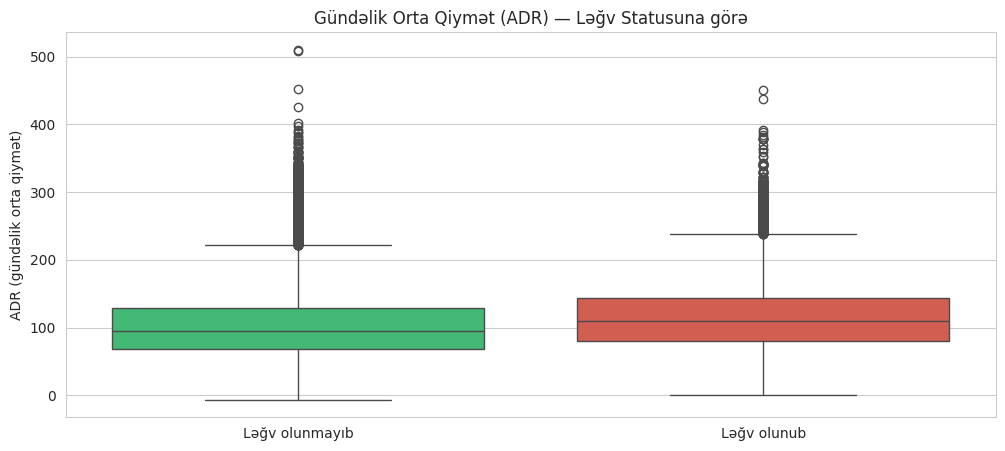

In [ ]:
# --- 4.6 ADR (Average Daily Rate) Paylanması ---
# Kənar dəyərləri (outliers) daha yaxşı görmək üçün ADR-i 0-dan 600-ə qədər məhdudlaşdırırıq
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df["adr"] < 600], x="is_canceled", y="adr", palette=["#2ecc71", "#e74c3c"])
plt.title("Gündəlik Orta Qiymət (ADR) — Ləğv Statusuna görə")
plt.xticks([0, 1], ["Ləğv olunmayıb", "Ləğv olunub"])
plt.xlabel("")
plt.ylabel("ADR (gündəlik orta qiymət)")
plt.show()

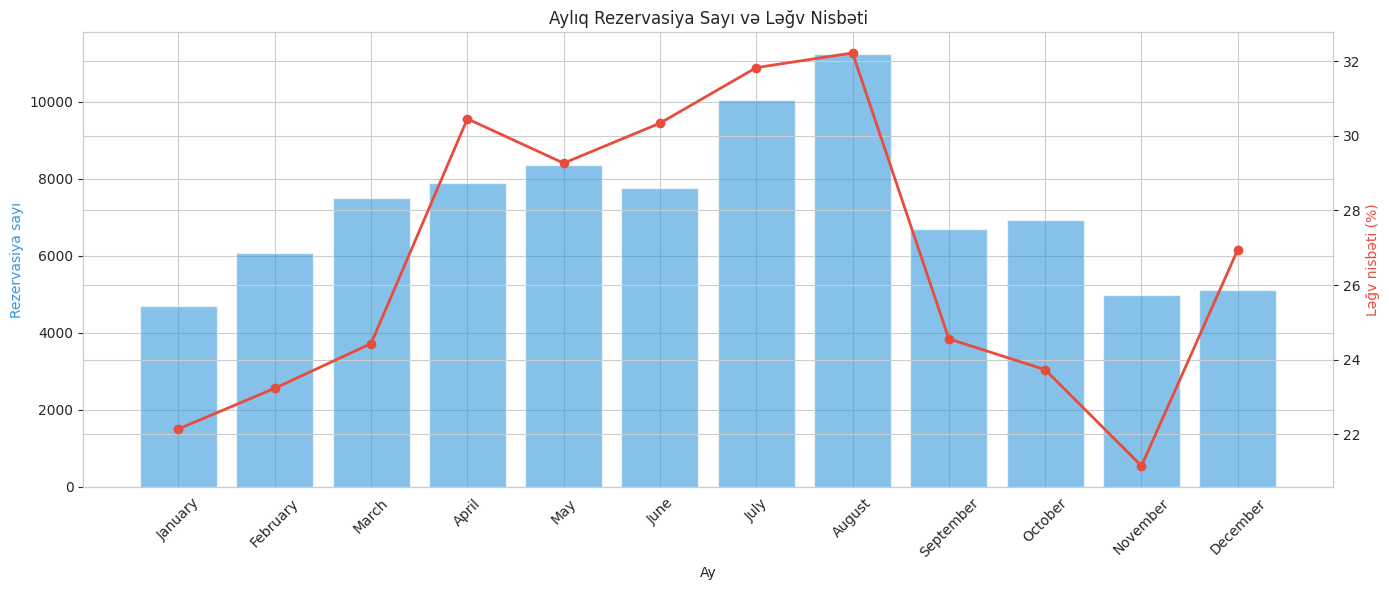

In [ ]:
# --- 4.7 Aylıq Rezervasiya Trendi ---
# Ayları düzgün xronoloji sırada göstərmək üçün kateqorik sıra təyin edirik
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=month_order, ordered=True)

monthly = df.groupby("arrival_date_month", observed=True).agg(
    total_bookings=("is_canceled", "count"),
    cancellation_rate=("is_canceled", "mean")
).reset_index()
monthly["cancellation_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Sol ox (bar): aylıq ümumi rezervasiya sayı
ax1.bar(monthly["arrival_date_month"], monthly["total_bookings"], color="#3498db", alpha=0.6, label="Rezervasiya sayı")
ax1.set_xlabel("Ay")
ax1.set_ylabel("Rezervasiya sayı", color="#3498db")
ax1.tick_params(axis="x", rotation=45)

# Sağ ox (line): aylıq ləğv nisbəti
ax2 = ax1.twinx()
ax2.plot(monthly["arrival_date_month"], monthly["cancellation_rate"], color="#e74c3c", marker="o", linewidth=2, label="Ləğv nisbəti (%)")
ax2.set_ylabel("Ləğv nisbəti (%)", color="#e74c3c")

plt.title("Aylıq Rezervasiya Sayı və Ləğv Nisbəti")
fig.tight_layout()
plt.show()

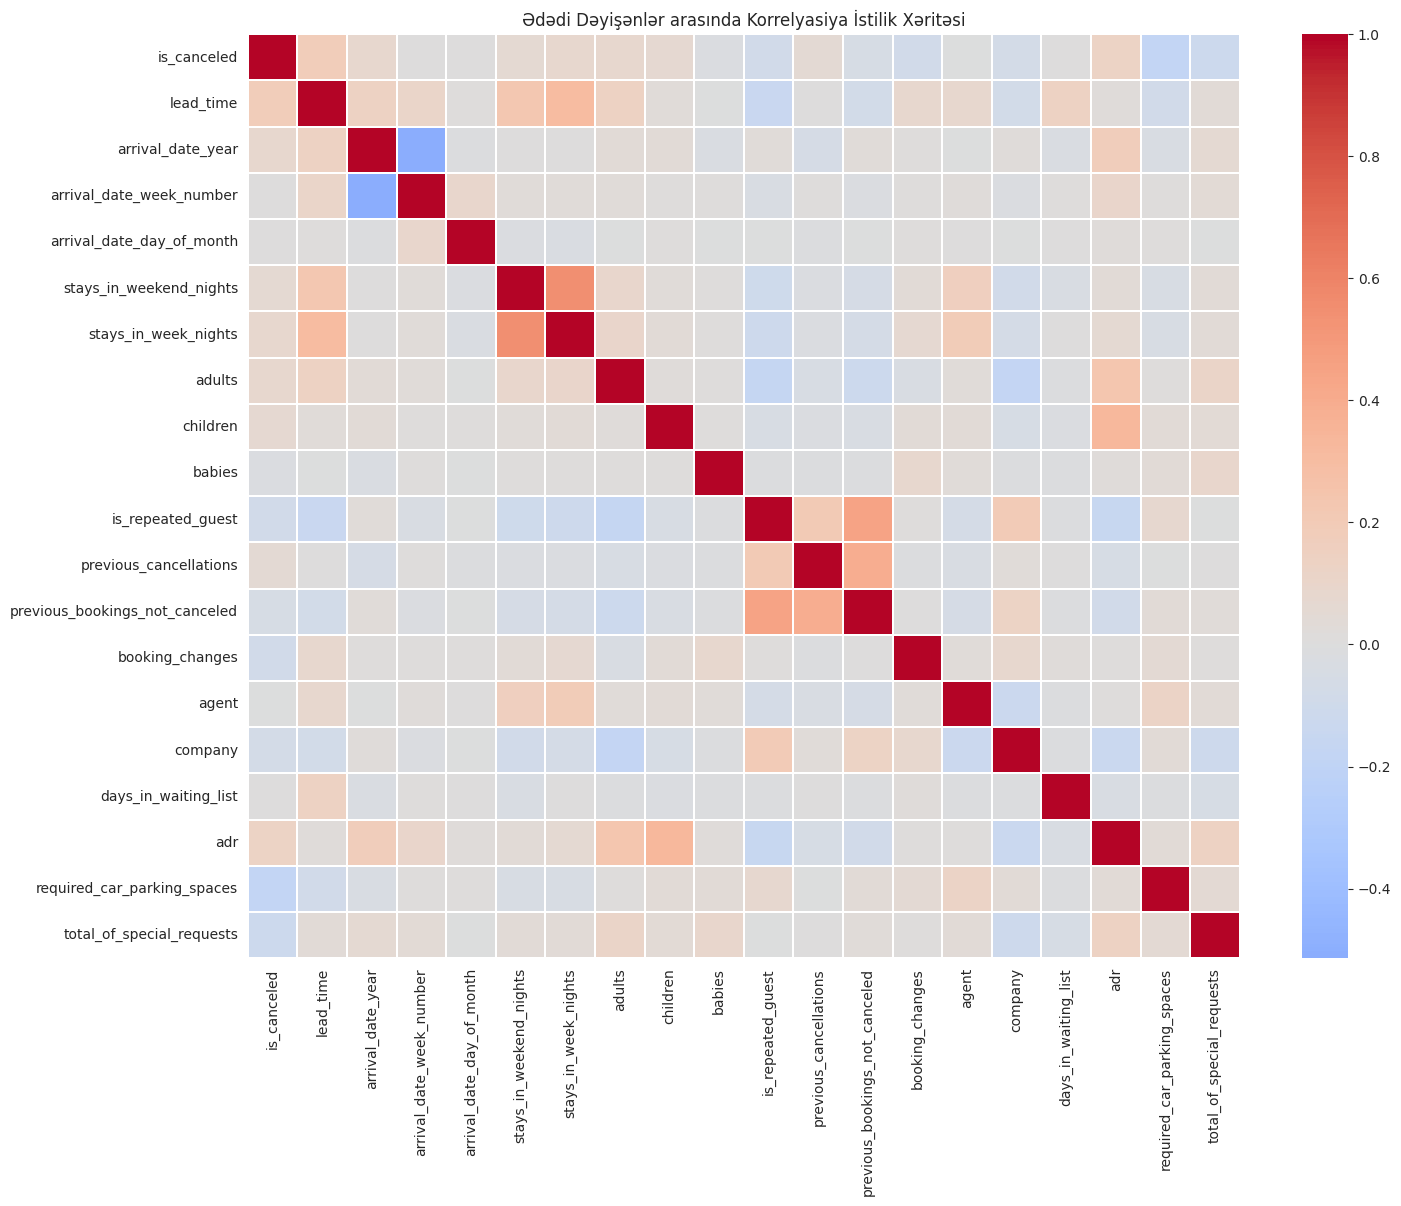

📌 'is_canceled' ilə ən çox korrelyasiyalı 10 dəyişən:
required_car_parking_spaces    0.184501
lead_time                      0.184433
adr                            0.127212
total_of_special_requests      0.120829
booking_changes                0.093275
is_repeated_guest              0.088791
arrival_date_year              0.088022
stays_in_week_nights           0.084088
adults                         0.080171
company                        0.075268
Name: is_canceled, dtype: float64


In [ ]:
# --- 4.8 Correlation Heatmap (Korrelyasiya İstilik Xəritəsi) ---
# Yalnız ədədi sütunlar arasındakı xətti əlaqəni ölçürük
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Ədədi Dəyişənlər arasında Korrelyasiya İstilik Xəritəsi")
plt.show()

# is_canceled ilə ən çox əlaqəli olan 10 dəyişəni ayrıca göstəririk
top_corr = corr_matrix["is_canceled"].drop("is_canceled").abs().sort_values(ascending=False).head(10)
print("📌 'is_canceled' ilə ən çox korrelyasiyalı 10 dəyişən:")
print(top_corr)

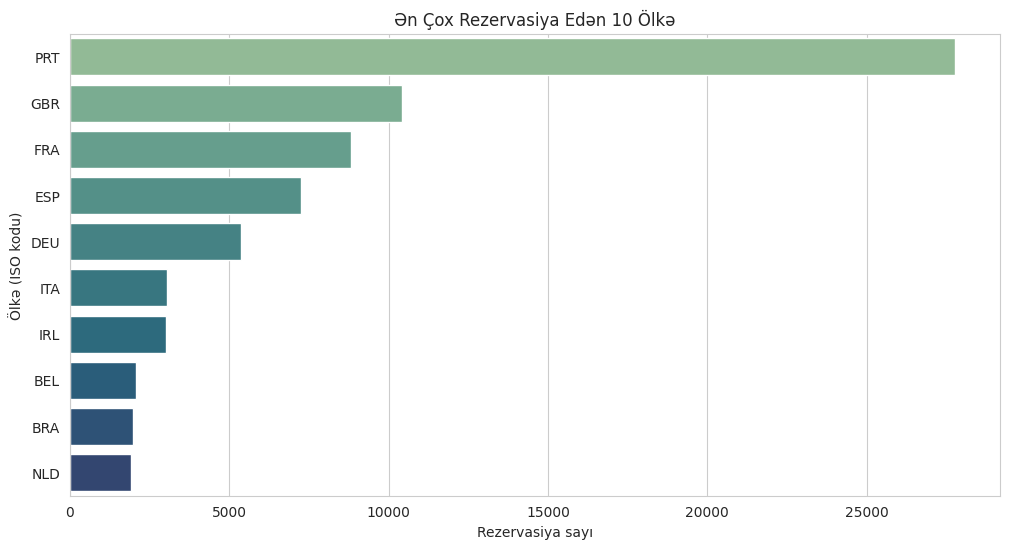

In [ ]:
# --- 4.9 Top 10 Ölkə üzrə Rezervasiya Sayı ---
plt.figure(figsize=(12, 6))
top_countries = df["country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="crest")
plt.title("Ən Çox Rezervasiya Edən 10 Ölkə")
plt.xlabel("Rezervasiya sayı")
plt.ylabel("Ölkə (ISO kodu)")
plt.show()

---
## 5 — Feature Engineering

Bu mərhələdə mövcud sütunlardan modelin daha yaxşı öyrənməsinə kömək edəcək yeni dəyişənlər ("feature"lər) yaradırıq.

In [ ]:
# --- total_nights: rezervasiyanın ümumi gecə sayı (həftə sonu + iş günü gecələri) ---
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# --- total_guests: ümumi qonaq sayı (böyük + uşaq + körpə) ---
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

# --- revenue: gözlənilən gəlir = gündəlik orta qiymət (ADR) × ümumi gecə sayı ---
df["revenue"] = df["adr"] * df["total_nights"]

# --- season: giriş ayına əsasən fəsil təyin edirik ---
season_map = {
    "December": "Winter", "January": "Winter", "February": "Winter",
    "March": "Spring", "April": "Spring", "May": "Spring",
    "June": "Summer", "July": "Summer", "August": "Summer",
    "September": "Autumn", "October": "Autumn", "November": "Autumn"
}
df["season"] = df["arrival_date_month"].astype(str).map(season_map)

# --- previous_total: müştərinin əvvəlki bütün rezervasiya sayı (ləğv olunan + olunmayan) ---
df["previous_total"] = df["previous_cancellations"] + df["previous_bookings_not_canceled"]

# --- family: ailə ilə səyahət edir ya yox (uşaq və ya körpə varsa = 1) ---
df["family"] = ((df["children"] > 0) | (df["babies"] > 0)).astype(int)

# --- is_domestic: ölkə 'PRT' (Portuqaliya, ən çox rast gəlinən ölkə) olarsa yerli müştəri sayılır ---
# Bu bonus feature-dir — otelin yerli/xarici müştəri seqmentasiyasını başa düşməyə kömək edir
df["is_domestic"] = (df["country"] == "PRT").astype(int)

# --- room_mismatch: sifariş edilən otaq növü ilə verilən otaq növü fərqlidirsə = 1 ---
# Bu, otelin gözlənilməz dəyişiklik etdiyini göstərir və ləğv riski ilə əlaqəli ola bilər
df["room_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

print("✅ Yeni yaradılan sütunlar:")
new_cols = ["total_nights", "total_guests", "revenue", "season", "previous_total",
            "family", "is_domestic", "room_mismatch"]
df[new_cols].head()

✅ Yeni yaradılan sütunlar:


,total_nights,total_guests,revenue,season,previous_total,family,is_domestic,room_mismatch
0,0,2,0.0,Summer,0,0,1,0
1,0,2,0.0,Summer,0,0,1,0
2,1,1,75.0,Summer,0,0,0,1
3,1,1,75.0,Summer,0,0,0,0
4,2,2,196.0,Summer,0,0,0,0


In [ ]:
# Yeni yaradılan ədədi sütunların qısa statistikasına baxaq
df[["total_nights", "total_guests", "revenue", "previous_total"]].describe().T

,count,mean,std,min,25%,50%,75%,max
total_nights,87211.0,3.628911,2.743065,0.0,2.0,3.0,5.0,69.0
total_guests,87211.0,2.029251,0.790135,1.0,2.0,2.0,2.0,55.0
revenue,87211.0,395.001738,369.450664,-63.8,153.0,299.2,504.0,7590.0
previous_total,87211.0,0.214503,1.908437,0.0,0.0,0.0,0.0,78.0


In [ ]:
# --- total_nights = 0 olan sətirləri təmizləyirik (heç gecələmədən rezervasiya məntiqsizdir) ---
zero_nights = (df["total_nights"] == 0)
print(f"total_nights = 0 olan sətir sayı: {zero_nights.sum()}")
df = df[~zero_nights].reset_index(drop=True)
print(f"Təmizləndikdən sonra son sətir sayı: {df.shape[0]}")

total_nights = 0 olan sətir sayı: 591
Təmizləndikdən sonra son sətir sayı: 86620


---
## 6 — Feature Selection

Modelə lazımsız və ya **data leakage** (məlumat sızması) yaradan sütunları silirik.

> Data Leakage `reservation_status` sütunu birbaşa `is_canceled` dəyişəninin nəticəsini əks etdirir (məs. "Canceled" statusu = ləğv olunub). Əgər bu sütunu modelə versək, model "gələcəyi bilir" kimi süni şəkildə mükəmməl nəticə göstərəcək, amma real həyatda işə yaramayacaq — çünki proqnoz anında bu status hələ məlum olmur.

In [ ]:
# Data leakage yaradan və proqnoz məqsədi üçün faydasız olan sütunları müəyyən edirik
leakage_cols = ["reservation_status", "reservation_status_date"]

# Unikal identifikator xarakterli, modelə heç bir siqnal verməyən sütunlar
id_like_cols = ["agent", "company"]   # çox sayda unikal kateqoriyaya malikdirlər, sadələşdirmək üçün çıxarırıq

cols_to_drop = leakage_cols + id_like_cols

df_model = df.drop(columns=cols_to_drop)

print(f"Silinən sütunlar: {cols_to_drop}")
print(f"Modelləşdirmə üçün qalan sütun sayı: {df_model.shape[1]}")

Silinən sütunlar: ['reservation_status', 'reservation_status_date', 'agent', 'company']
Modelləşdirmə üçün qalan sütun sayı: 36


In [ ]:
# Hədəf dəyişəni (target) ayırırıq
target_col = "is_canceled"

# Feature (X) və target (y) olaraq ayırırıq
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print(f"X ölçüsü: {X.shape}")
print(f"y ölçüsü: {y.shape}")
print(f"Target balansı:\n{y.value_counts(normalize=True)}")

X ölçüsü: (86620, 35)
y ölçüsü: (86620,)
Target balansı:
is_canceled
0    0.723101
1    0.276899
Name: proportion, dtype: float64


In [ ]:
# Ədədi (numeric) və kateqorik (categorical) sütunları ayrıca siyahılara bölürük —
# bu, Preprocessing Pipeline mərhələsində lazım olacaq
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Ədədi (numeric) sütunlar ({len(numeric_features)} ədəd):\n{numeric_features}\n")
print(f"Kateqorik (categorical) sütunlar ({len(categorical_features)} ədəd):\n{categorical_features}")

Ədədi (numeric) sütunlar (24 ədəd):
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'revenue', 'previous_total', 'family', 'is_domestic', 'room_mismatch']

Kateqorik (categorical) sütunlar (11 ədəd):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'season']


---
## 7 — Train / Test Split

Datamızı 80% train (öyrətmə) və 20% test (yoxlama) hissələrinə bölürük. `stratify=y` istifadə edirik ki, hər iki hissədə ləğv nisbəti eyni proporsiyada saxlanılsın (balanssız data üçün vacibdir).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # datanın 20%-i test üçün ayrılır
    random_state=42,       # nəticələrin təkrarlana bilməsi üçün sabit "toxum" (seed)
    stratify=y              # train və test setlərində target balansını qoruyur
)

print(f"Train set ölçüsü: {X_train.shape}")
print(f"Test set ölçüsü:  {X_test.shape}")
print(f"\nTrain set-də ləğv nisbəti: {y_train.mean():.3f}")
print(f"Test set-də ləğv nisbəti:  {y_test.mean():.3f}")

Train set ölçüsü: (69296, 35)
Test set ölçüsü:  (17324, 35)

Train set-də ləğv nisbəti: 0.277
Test set-də ləğv nisbəti:  0.277


---
## 8 — Preprocessing Pipeline

Burada `Pipeline` və `ColumnTransformer` istifadə edərək bütün preprocessing addımlarını (imputasiya, miqyaslama, kodlaşdırma) tək bir obyektə birləşdiririk. Bu yanaşma:
- Data sızmasının (leakage) qarşısını alır (çünki `fit` yalnız train datasında aparılır),
- Kodu təmiz və təkrar istifadə edilə bilən edir,
- Yeni datanın (məsələn, What-If Simulator-da) eyni transformasiyalardan keçməsini asanlaşdırır.

In [ ]:
# --- Ədədi sütunlar üçün pipeline ---
# 1) Imputer: boş dəyərləri median (median) ilə doldurur (outlier-lərə qarşı davamlıdır)
# 2) Scaler: bütün ədədi dəyərləri eyni miqyasa (mean=0, std=1) gətirir
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# --- Kateqorik sütunlar üçün pipeline ---
# 1) Imputer: boş dəyərləri ən çox rast gəlinən kateqoriya (most_frequent) ilə doldurur
# 2) OneHotEncoder: hər kateqoriyanı ayrı binar (0/1) sütuna çevirir
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# --- ColumnTransformer: yuxarıdakı iki pipeline-ı müvafiq sütun qruplarına tətbiq edir ---
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("✅ Preprocessing Pipeline hazırdır.")


✅ Preprocessing Pipeline hazırdır.


---
## 9 — Baseline Modellər

Üç fərqli modeli öyrədib müqayisə edəcəyik: **Logistic Regression** (sadə, izah edilə bilən baseline), **Random Forest** (ensemble, qeyri-xətti əlaqələri tuta bilən) və **XGBoost** (güclü gradient boosting modeli).

Hər model üçün bu funksiyanı istifadə edəcəyik ki, kodu təkrarlamayaq (DRY prinsipi).

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Verilən modeli öyrədir, test datasında qiymətləndirir və
    əsas metrikaları (Accuracy, Precision, Recall, F1, ROC-AUC) qaytarır.
    Həmçinin Confusion Matrix və ROC Curve çəkir.
    """
    # Modeli train datası üzərində öyrədirik
    model.fit(X_train, y_train)

    # Test datası üçün proqnozlar alırıq
    y_pred = model.predict(X_test)
    # Müsbət sinifin (ləğv olunma) ehtimalını alırıq — ROC-AUC üçün lazımdır
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrikaları hesablayırıq
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    # Nəticələri ekrana çıxarırıq
    print(f"\n{'='*50}")
    print(f"📊 {model_name} — Nəticələr")
    print(f"{'='*50}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k:12s}: {v:.4f}")

    # Confusion Matrix və ROC Curve-ü yan-yana çəkirik
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0],
                                             display_labels=["Ləğv olunmayıb", "Ləğv olunub"],
                                             cmap="Blues")
    ax[0].set_title(f"{model_name} — Confusion Matrix")

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1], name=model_name)
    ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    ax[1].set_title(f"{model_name} — ROC Curve")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    return metrics, model


📊 Logistic Regression — Nəticələr
Accuracy    : 0.7938
Precision   : 0.6760
Recall      : 0.4905
F1          : 0.5685
ROC-AUC     : 0.8481


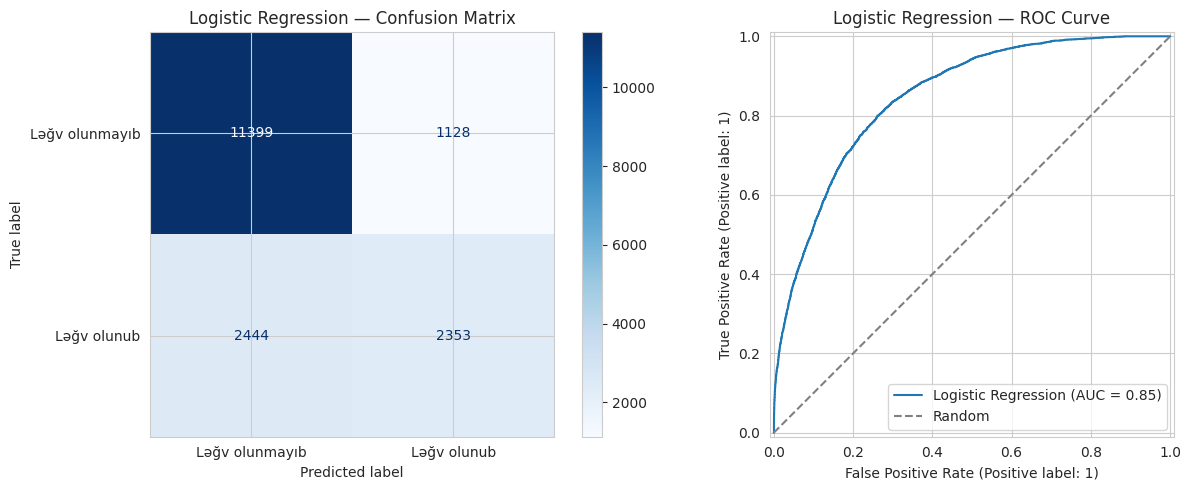

In [ ]:
# --- Model 1: Logistic Regression ---
# Sadə, sürətli, izah edilə bilən xətti model — baseline üçün ideal başlanğıc nöqtəsi
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),                                     # əvvəlki mərhələdə qurduğumuz preprocessing
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))  # max_iter artırılıb ki, model konverqensiya etsin
])

logreg_metrics, logreg_model = evaluate_model(
    logreg_pipeline, X_train, y_train, X_test, y_test, "Logistic Regression"
)


📊 Random Forest — Nəticələr
Accuracy    : 0.8234
Precision   : 0.8071
Recall      : 0.4761
F1          : 0.5989
ROC-AUC     : 0.8917


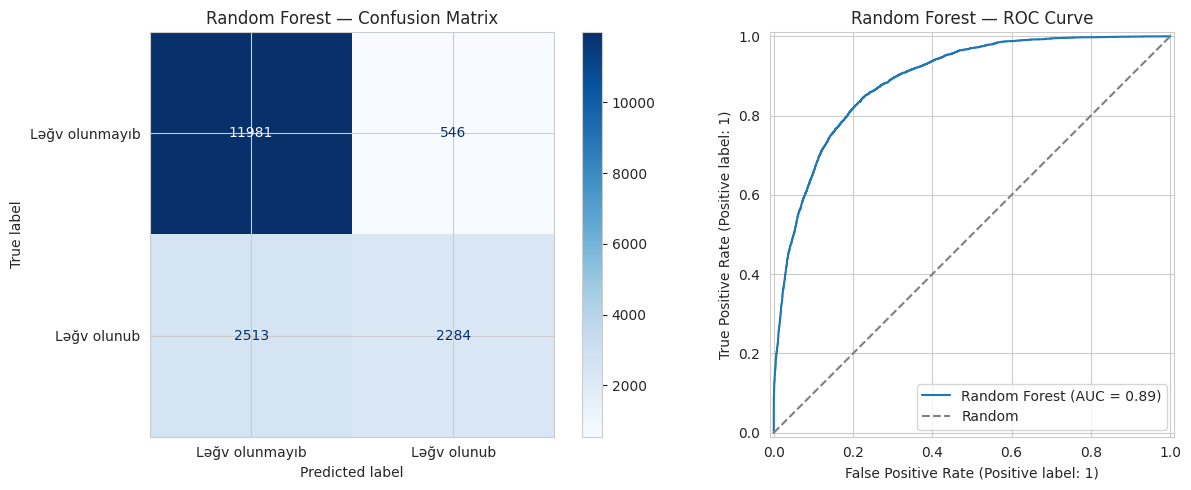

In [ ]:
# --- Model 2: Random Forest ---
# Çoxlu qərar ağacından (decision tree) ibarət ensemble model
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,      # 200 ağac qururuq — daha çox ağac = daha stabil, amma daha yavaş
        max_depth=15,          # ağacların dərinliyini məhdudlaşdırırıq ki, overfitting olmasın
        random_state=42,
        n_jobs=-1               # bütün CPU nüvələrindən istifadə edərək paralel hesablama aparır
    ))
])

rf_metrics, rf_model = evaluate_model(
    rf_pipeline, X_train, y_train, X_test, y_test, "Random Forest"
)


📊 XGBoost — Nəticələr
Accuracy    : 0.8471
Precision   : 0.7547
Recall      : 0.6633
F1          : 0.7061
ROC-AUC     : 0.9086


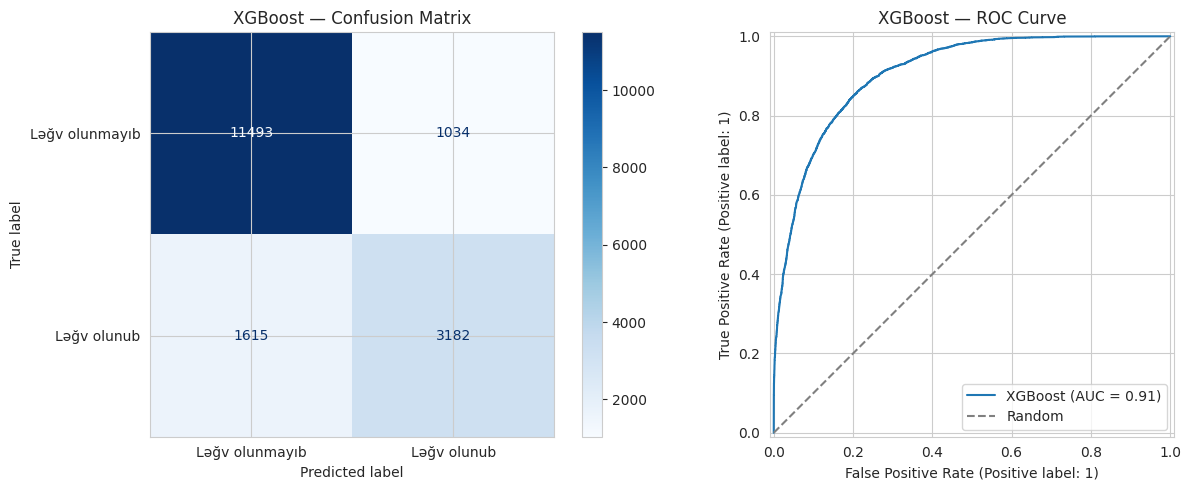

In [ ]:
# --- Model 3: XGBoost ---
# Gradient boosting alqoritmi
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,             # hər ağac üçün datanın 80%-ini təsadüfi seçir (overfitting-in qarşısını alır)
        colsample_bytree=0.8,      # hər ağac üçün sütunların 80%-ini təsadüfi seçir
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_metrics, xgb_model = evaluate_model(
    xgb_pipeline, X_train, y_train, X_test, y_test, "XGBoost"
)

---
## 10 — Model Comparison

Üç modelin nəticələrini bir cədvəldə və qrafikdə müqayisə edirik.

In [ ]:
# Bütün modellərin metrikalarını bir DataFrame-də birləşdiririk
comparison_df = pd.DataFrame([logreg_metrics, rf_metrics, xgb_metrics]).set_index("Model")
comparison_df = comparison_df.round(4)

# Cədvəli rəngli formatda göstəririk (ən yaxşı dəyər yaşıl rənglə vurğulanır)
comparison_df.style.background_gradient(cmap="Greens", axis=0)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.793800,0.676000,0.490500,0.568500,0.848100
Random Forest,0.823400,0.807100,0.476100,0.598900,0.891700
XGBoost,0.847100,0.754700,0.663300,0.706100,0.908600


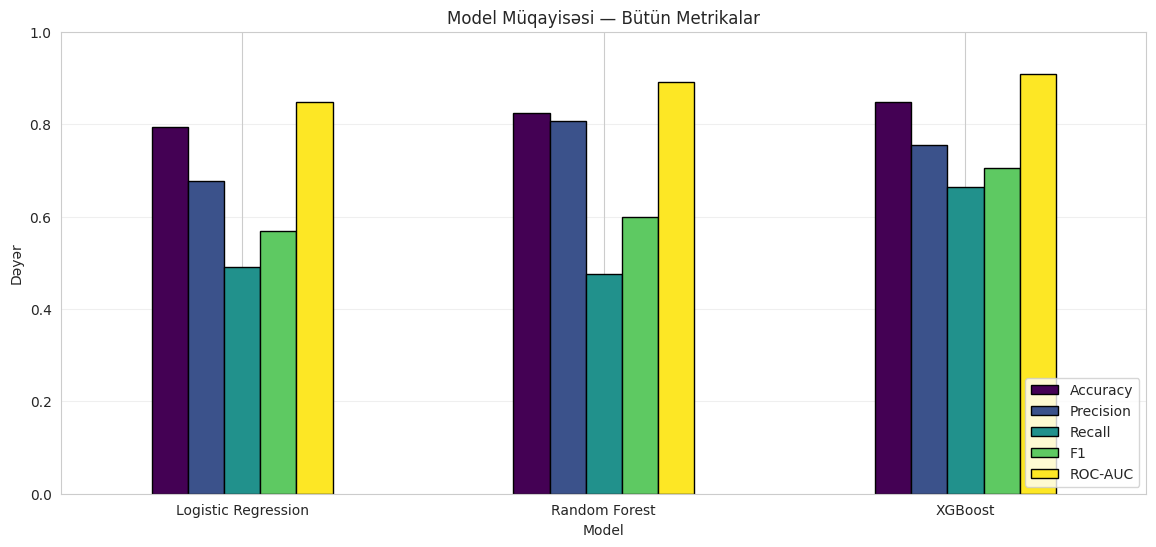

In [ ]:
# Metrikaları qrupplaşdırılmış bar chart ilə vizuallaşdırırıq
comparison_df.plot(kind="bar", figsize=(14, 6), colormap="viridis", edgecolor="black")
plt.title("Model Müqayisəsi — Bütün Metrikalar")
plt.ylabel("Dəyər")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

---
## 11 — Qalib Model

Ən yüksək **ROC-AUC** və **Recall** göstəricilərinə görə qalib modeli seçirik. Bizim üçün **Recall** xüsusilə vacibdir, çünki ləğv ediləcək rezervasiyanı buraxmamaq (yəni False Negative sayını azaltmaq) biznes baxımından daha bahalı bir səhvin qarşısını alır.

In [ ]:
# ROC-AUC-a görə ən yaxşı modeli avtomatik seçirik
best_model_name = comparison_df["ROC-AUC"].idxmax()
print(f"🏆 Qalib model: {best_model_name}")
print(f"   ROC-AUC: {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"   Recall:  {comparison_df.loc[best_model_name, 'Recall']:.4f}")

# Modeli dəyişənə mənimsədirik ki, sonrakı mərhələlərdə istifadə edək
models_dict = {"Logistic Regression": logreg_pipeline, "Random Forest": rf_pipeline, "XGBoost": xgb_pipeline}
champion_pipeline = models_dict[best_model_name]

🏆 Qalib model: XGBoost
   ROC-AUC: 0.9086
   Recall:  0.6633


---
##  12 — Hyperparameter Tuning

`RandomizedSearchCV` istifadə edərək qalib modelin hiperparametrlərini optimallaşdırırıq. `RandomizedSearchCV` bütün kombinasiyaları yoxlamaq əvəzinə (`GridSearchCV` kimi) təsadüfi seçilmiş kombinasiyaları sınayır — bu, daha sürətlidir və böyük parametr fəzalarında da effektivdir.


In [ ]:
# XGBoost üçün hiperparametr axtarış fəzasını təyin edirik
param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 400, 500],
    "classifier__max_depth": [3, 4, 5, 6, 7, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__gamma": [0, 0.1, 0.2, 0.3]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=25,                 # 25 təsadüfi kombinasiya sınanacaq
    scoring="roc_auc",         # optimallaşdırma meyarı — ROC-AUC
    cv=3,                       # 3-qat cross-validation
    verbose=2,                  # prosesin gedişatını ətraflı göstərir
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"\n Ən yaxşı parametrlər:\n{random_search.best_params_}")
print(f"\n Ən yaxşı CV ROC-AUC skoru: {random_search.best_score_:.4f}")

tuned_model = random_search.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits

 Ən yaxşı parametrlər:
{'classifier__subsample': 1.0, 'classifier__n_estimators': 300, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.2, 'classifier__gamma': 0.3, 'classifier__colsample_bytree': 0.9}

 Ən yaxşı CV ROC-AUC skoru: 0.9073



📊 XGBoost (Tuned) — Nəticələr
Accuracy    : 0.8504
Precision   : 0.7551
Recall      : 0.6806
F1          : 0.7159
ROC-AUC     : 0.9126


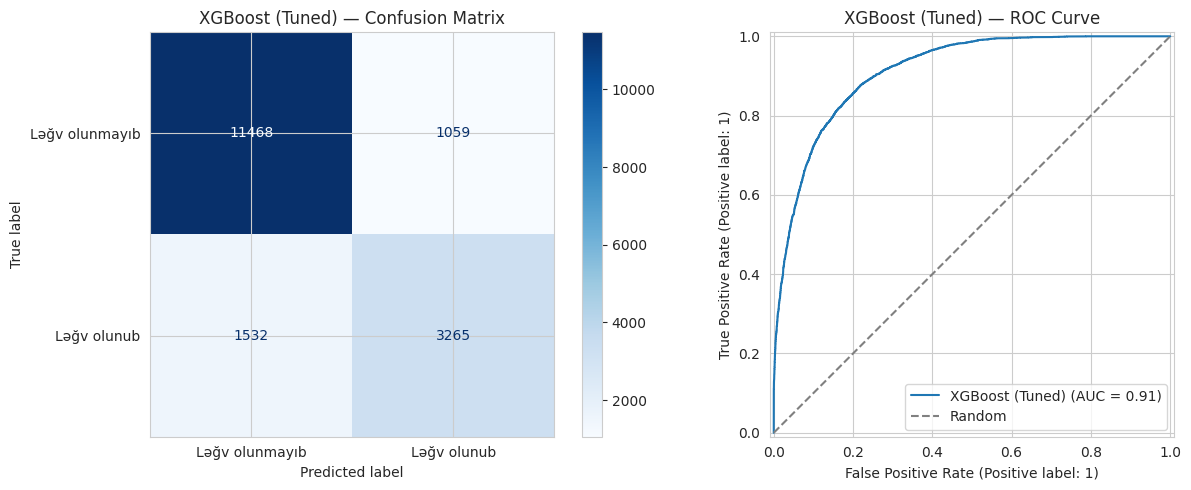

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost (Default),0.8471,0.7547,0.6633,0.7061,0.9086
XGBoost (Tuned),0.8504,0.7551,0.6806,0.7159,0.9126


In [ ]:
# Tunlanmış modeli test datasında qiymətləndiririk
tuned_metrics, _ = evaluate_model(tuned_model, X_train, y_train, X_test, y_test, "XGBoost (Tuned)")

# Tunlamadan əvvəl və sonra nəticələri müqayisə edirik
before_after = pd.DataFrame([xgb_metrics, tuned_metrics]).set_index("Model")
before_after.index = ["XGBoost (Default)", "XGBoost (Tuned)"]
before_after.round(4)

---
## 13 — Cross Validation

Modelin müxtəlif data bölgülərində stabil işlədiyini göstərmək üçün **5-Fold Cross Validation** aparırıq. Bu, modelin nəticələrinin təsadüfi bir train/test bölgüsünə görə şişirdilmədiyini sübut edir.

In [ ]:
# StratifiedKFold istifadə edirik ki, hər "fold"-da target balansı qorunsun
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate bir neçə metrikanı eyni zamanda hesablamağa imkan verir
cv_results = cross_validate(
    tuned_model, X, y,          # bütün datasetdə (X, y) CV aparırıq ki, hər fold fərqli test payı görsün
    cv=cv_strategy,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

# Nəticələri səliqəli cədvəldə göstəririk
cv_summary = pd.DataFrame({
    "Metrika": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Orta": [cv_results[f"test_{m}"].mean() for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]],
    "Standart Sapma": [cv_results[f"test_{m}"].std() for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]]
})
cv_summary.round(4)

,Metrika,Orta,Standart Sapma
0,Accuracy,0.8478,0.0027
1,Precision,0.7506,0.0047
2,Recall,0.6742,0.0065
3,F1,0.7104,0.0057
4,ROC-AUC,0.9115,0.0022


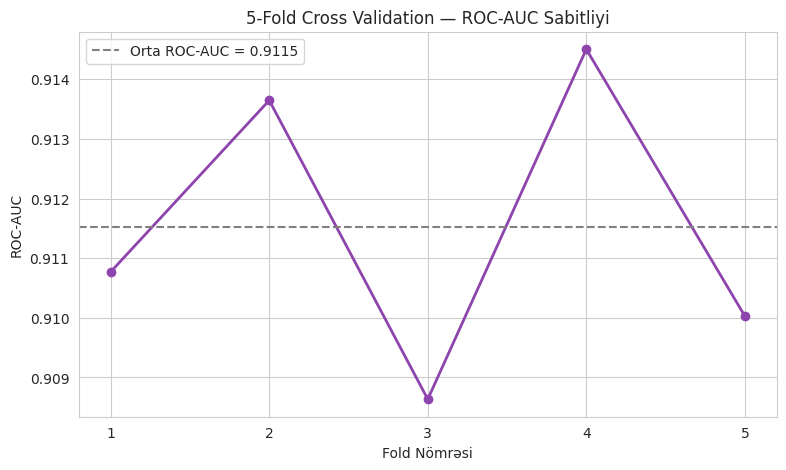

In [ ]:
# 5 fold üzrə ROC-AUC dəyərlərini vizuallaşdırırıq — stabilliyi göstərmək üçün
plt.figure(figsize=(9, 5))
folds = range(1, 6)
plt.plot(folds, cv_results["test_roc_auc"], marker="o", linewidth=2, color="#8e44ad")
plt.axhline(cv_results["test_roc_auc"].mean(), linestyle="--", color="gray",
            label=f"Orta ROC-AUC = {cv_results['test_roc_auc'].mean():.4f}")
plt.title("5-Fold Cross Validation — ROC-AUC Sabitliyi")
plt.xlabel("Fold Nömrəsi")
plt.ylabel("ROC-AUC")
plt.xticks(folds)
plt.legend()
plt.show()

---
## 14 — Threshold Optimization

Default olaraq təsnifat üçün 0.5 threshold istifadə olunur (yəni ehtimal 0.5-dən yuxarıdırsa "ləğv olunacaq" deyilir). Lakin biznes məqsədimiz (ləğvləri daha yaxşı tutmaq) üçün bu, optimal olmaya bilər. Precision-Recall əyrisindən istifadə edərək ən uyğun threshold-u tapırıq.

In [ ]:
# Test datası üçün ehtimal proqnozlarını alırıq
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

# Fərqli threshold-lar üçün precision və recall dəyərlərini hesablayırıq
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_tuned)

# F1 skorunu hər threshold üçün hesablayırıq və ən yüksək F1-i verən threshold-u seçirik
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f" Default threshold: 0.50")
print(f" Optimal threshold (ən yüksək F1-ə görə): {best_threshold:.3f}")
print(f"  Bu nöqtədə Precision: {precisions[best_threshold_idx]:.4f}")
print(f"  Bu nöqtədə Recall:    {recalls[best_threshold_idx]:.4f}")
print(f"  Bu nöqtədə F1:        {f1_scores[best_threshold_idx]:.4f}")

 Default threshold: 0.50
 Optimal threshold (ən yüksək F1-ə görə): 0.405
  Bu nöqtədə Precision: 0.7099
  Bu nöqtədə Recall:    0.7603
  Bu nöqtədə F1:        0.7342


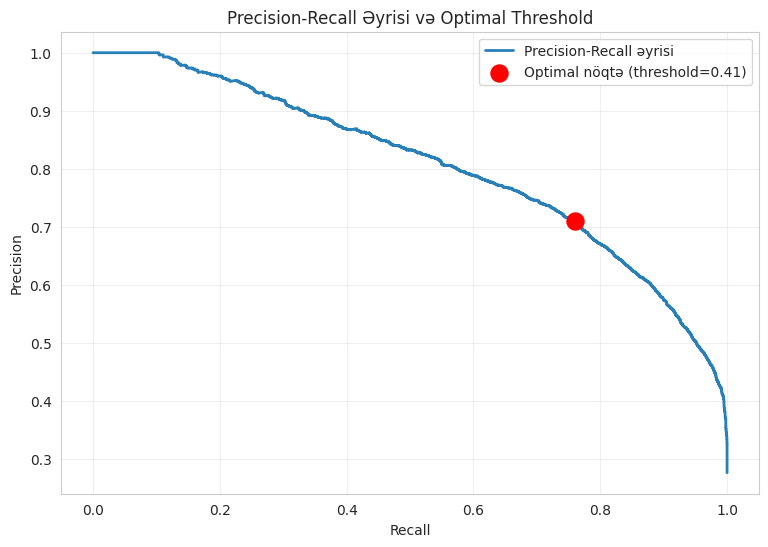

In [ ]:
# Precision-Recall əyrisini vizuallaşdırırıq və optimal nöqtəni işarələyirik
plt.figure(figsize=(9, 6))
plt.plot(recalls, precisions, color="#2980b9", linewidth=2, label="Precision-Recall əyrisi")
plt.scatter(recalls[best_threshold_idx], precisions[best_threshold_idx],
            color="red", s=150, zorder=5, label=f"Optimal nöqtə (threshold={best_threshold:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Əyrisi və Optimal Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Optimal threshold ilə yeni proqnozlar yaradırıq və default threshold ilə müqayisə edirik
y_pred_default = (y_proba_tuned >= 0.5).astype(int)
y_pred_optimal = (y_proba_tuned >= best_threshold).astype(int)

threshold_comparison = pd.DataFrame({
    "Threshold=0.50": [
        precision_score(y_test, y_pred_default), recall_score(y_test, y_pred_default), f1_score(y_test, y_pred_default)
    ],
    f"Threshold={best_threshold:.2f}": [
        precision_score(y_test, y_pred_optimal), recall_score(y_test, y_pred_optimal), f1_score(y_test, y_pred_optimal)
    ]
}, index=["Precision", "Recall", "F1"])

threshold_comparison.round(4)

,Threshold=0.50,Threshold=0.41
Precision,0.7551,0.7099
Recall,0.6806,0.7603
F1,0.7159,0.7342


---
## 15 — Explainable AI (SHAP)

Model *nəyə görə* bu qərarı verdi? Bunu cavablandırmaq üçün **SHAP (SHapley Additive exPlanations)** istifadə edirik. SHAP hər bir dəyişənin proqnoza nə qədər töhfə verdiyini ədədi olaraq göstərir.

- **Global Importance** — bütün dataset üzrə hansı dəyişənlərin ən vacib olduğunu göstərir.
- **Local Explanation** — konkret bir rezervasiya üçün nəyə görə "riskli" və ya "risksiz" qiymətləndirildiyini izah edir.

In [ ]:
# SHAP üçün preprocessing edilmiş datanı hazırlayırıq
X_test_transformed = tuned_model.named_steps["preprocessor"].transform(X_test)

# Preprocessing-dən sonrakı sütun adlarını əldə edirik (OneHotEncoder yeni sütunlar yaradıb)
feature_names_num = numeric_features
feature_names_cat = tuned_model.named_steps["preprocessor"].named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = list(feature_names_num) + list(feature_names_cat)

# XGBoost modelini pipeline-dan ayırırıq (SHAP TreeExplainer birbaşa modellə işləyir)
xgb_classifier = tuned_model.named_steps["classifier"]

# TreeExplainer — ağac əsaslı modellər (XGBoost, Random Forest) üçün sürətli SHAP hesablayıcı
explainer = shap.TreeExplainer(xgb_classifier)

# Hesablama vaxtına qənaət etmək üçün test datasından təsadüfi 1000 nümunə seçirik
sample_idx = np.random.RandomState(42).choice(X_test_transformed.shape[0], size=min(1000, X_test_transformed.shape[0]), replace=False)
X_sample = X_test_transformed[sample_idx]

shap_values = explainer.shap_values(X_sample)
print("✅ SHAP dəyərləri hesablandı.")

✅ SHAP dəyərləri hesablandı.


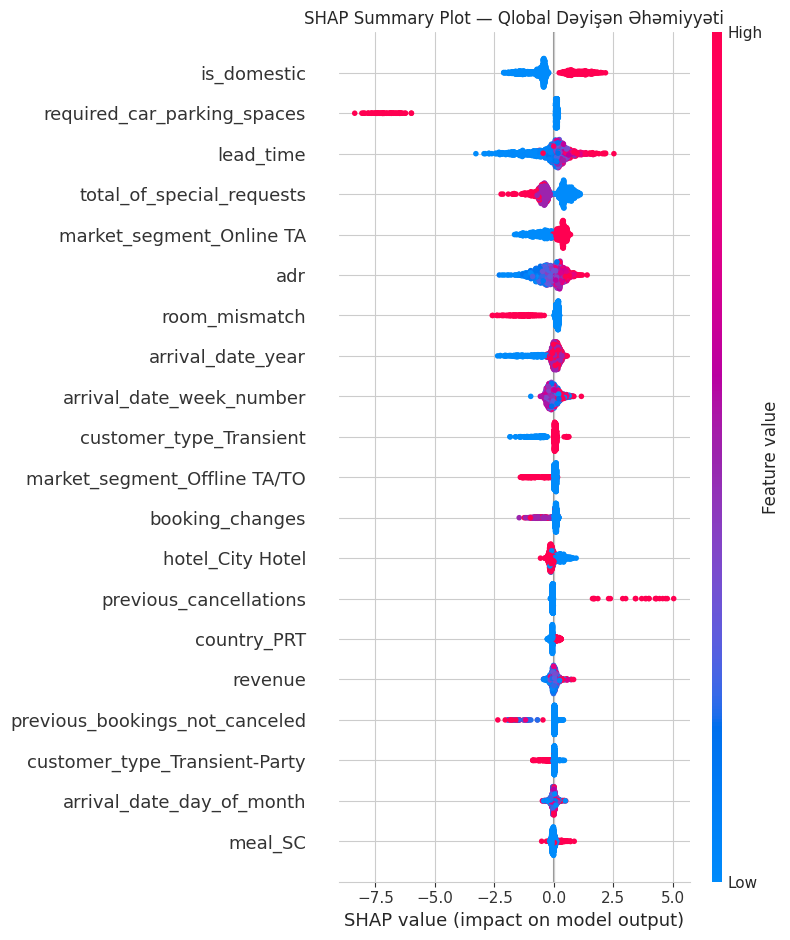

In [ ]:
# --- Global Importance: Summary Plot ---
# Hər dəyişənin ümumi əhəmiyyətini və proqnoza müsbət/mənfi təsirini göstərir
shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names, show=False)
plt.title("SHAP Summary Plot — Qlobal Dəyişən Əhəmiyyəti")
plt.tight_layout()
plt.show()

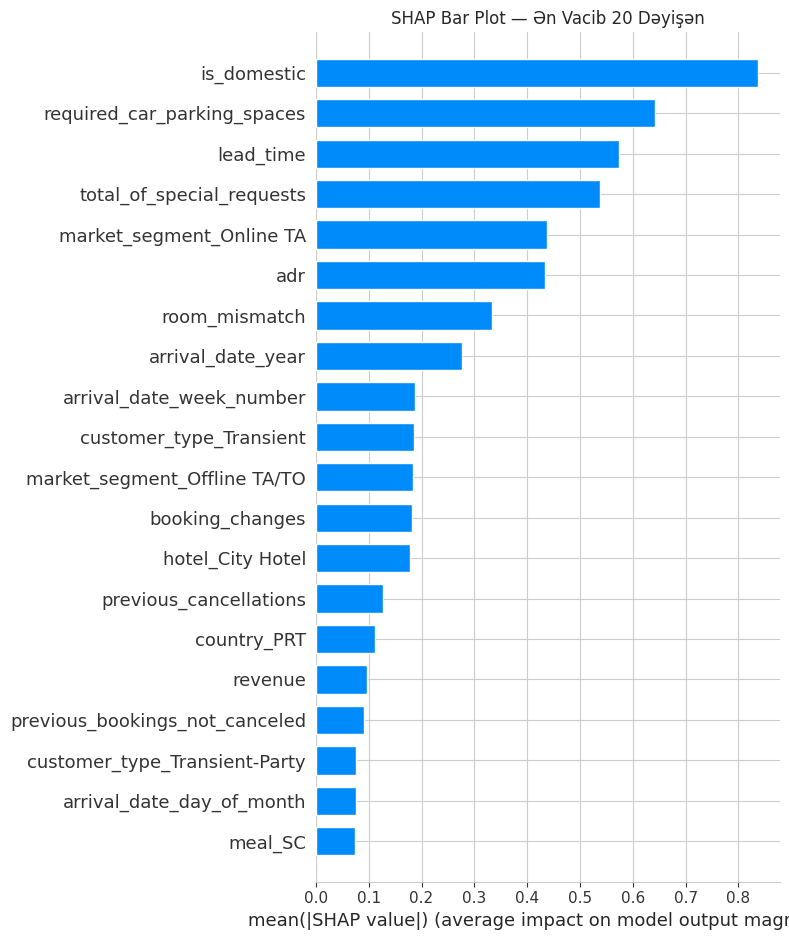

In [ ]:
# --- Global Importance: Bar Plot (sadələşdirilmiş versiya) ---
shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names, plot_type="bar", show=False)
plt.title("SHAP Bar Plot — Ən Vacib 20 Dəyişən")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

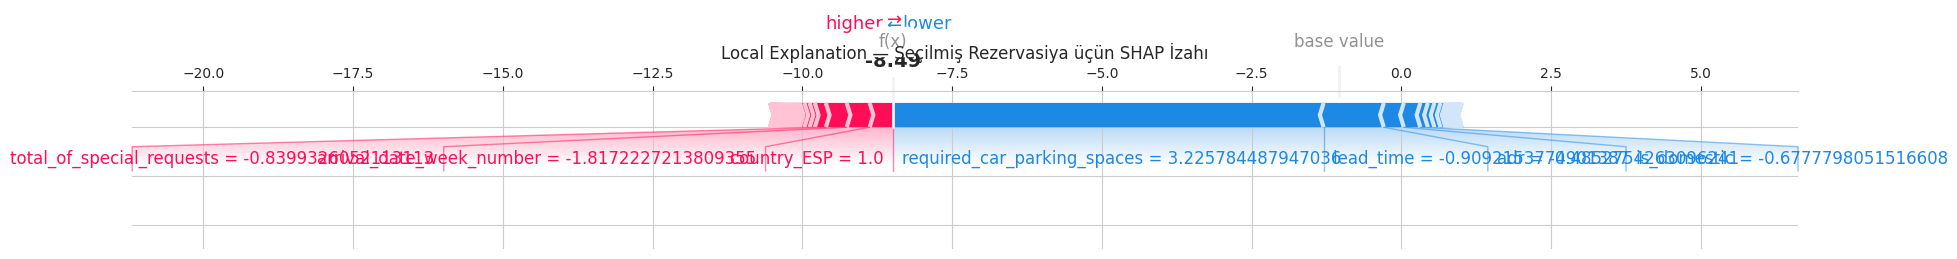

Qeyd: Qırmızı çubuqlar ləğv riskini artıran, mavi çubuqlar isə azaldan dəyişənlərdir.


In [ ]:
# --- Local Explanation: konkret bir rezervasiya üçün izah ---
# Test datasından təsadüfi bir rezervasiya seçirik və modelin niyə belə qərar verdiyini göstəririk
sample_index_to_explain = 0   # istənilən indeksi seçə bilərsiniz (0-999 arası)

plt.figure()
shap.force_plot(
    explainer.expected_value, shap_values[sample_index_to_explain, :],
    X_sample[sample_index_to_explain, :], feature_names=all_feature_names,
    matplotlib=True, show=False
)
plt.title("Local Explanation — Seçilmiş Rezervasiya üçün SHAP İzahı")
plt.tight_layout()
plt.show()

print("Qeyd: Qırmızı çubuqlar ləğv riskini artıran, mavi çubuqlar isə azaldan dəyişənlərdir.")

### 🤖 AI Risk Assistant — SHAP Nəticələrini Təbii Dilə Çevirmək (Bonus)

SHAP bizə **rəqəmsal** izah verir (hansı dəyişən nə qədər təsir edib), amma bu rəqəmləri hər zaman otel meneceri asanlıqla oxuya bilmir. Bu bölmədə SHAP-in nəticələrini bir **LLM (Groq — Llama 3.3 70B)** vasitəsilə sadə, insan dilində izaha çeviririk — sanki menecerə "Niyə bu rezervasiya risklidir?" sualına canlı cavab verən bir köməkçi.


In [ ]:
# Groq Python kitabxanasını quraşdırırıq
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 11.4 MB/s eta 0:00:00


In [ ]:
import groq
from getpass import getpass

# API açarını təhlükəsiz şəkildə daxil edirik
GROQ_API_KEY = getpass("Groq API açarınızı daxil edin: ")

client = groq.Groq(api_key=GROQ_API_KEY)

Groq API açarınızı daxil edin: ··········


In [ ]:
def explain_risk_with_ai(booking_index, shap_values, feature_names, X_sample_data, probability, model="llama-3.3-70b-versatile"):
    """
    Verilən bir rezervasiya üçün SHAP dəyərlərini götürür, ən çox təsir edən
    dəyişənləri müəyyən edir və Claude-dan sadə, biznes dilində izah istəyir.
    """
    # SHAP dəyərlərinin mütləq qiymətinə görə ən vacib 5 dəyişəni tapırıq
    row_shap = shap_values[booking_index, :]
    top_idx = np.argsort(np.abs(row_shap))[::-1][:5]

    # Hər dəyişən üçün: adı, real dəyəri və SHAP təsiri (müsbət = riski artırır, mənfi = azaldır)
    top_factors = []
    for idx in top_idx:
        factor_name = feature_names[idx]
        factor_value = X_sample_data[booking_index, idx]
        shap_impact = row_shap[idx]
        direction = "riski ARTIRIR" if shap_impact > 0 else "riski AZALDIR"
        top_factors.append(f"- {factor_name} (dəyəri: {factor_value:.2f}) → {direction} (SHAP təsiri: {shap_impact:+.3f})")

    factors_text = "\n".join(top_factors)

    # LLM üçün prompt hazırlayırıq — sadə, praktik, menecer üçün başa düşülən dildə istəyirik
    prompt = f"""Sən bir otel gəlir menecerinə kömək edən AI köməkçisisən.

Machine Learning modeli bu rezervasiya üçün ləğv ehtimalını {probability*100:.1f}% hesablayıb.

Bu ehtimala ən çox təsir edən amillər (SHAP analizindən, əhəmiyyət sırası ilə):
{factors_text}

Tapşırıq: Yuxarıdakı texniki məlumata əsasən, otel menecerinə 3-4 cümlə ilə, SADƏ və PRAKTİK
dildə (texniki terminlər olmadan) bu rezervasiyanın niyə riskli (və ya risksiz) olduğunu izah et.
Sonda 1 konkret tövsiyə ver (məsələn: depozit tələb et, xatırlatma göndər, və ya heç nə etmə).
Azərbaycan dilində, mentor təqdimatında istifadə edilə biləcək professional bir tonda cavab ver."""

    response = client.chat.completions.create(
        model=model,
        max_tokens=300,
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content

In [ ]:
# --- Nümunə: seçilmiş rezervasiya üçün AI izahı alırıq ---
# (sample_index_to_explain dəyişəni əvvəlki hüceyrədə artıq təyin olunub)
try:
    ai_explanation = explain_risk_with_ai(
        booking_index=sample_index_to_explain,
        shap_values=shap_values,
        feature_names=all_feature_names,
        X_sample_data=X_sample,
        probability=y_proba_tuned[sample_index_to_explain] if sample_index_to_explain < len(y_proba_tuned) else 0.5
    )

    print("🤖 AI Risk Assistant deyir:\n")
    print(ai_explanation)
except Exception as e:
    print(f"⚠️ Xəta baş verdi: {e}")
    print("Yoxlayın: API açarınız düzgündürmü? İnternet bağlantısı varmı?")

🤖 AI Risk Assistant deyir:

Bu rezervasiya üçün ləğv ehtimalı çox azdır, yəni riski aşağıdır. Səbəb odur ki, qonaqların avtomobil parkinqi üçün tələb etdiyi yerlərin sayı çoxdur, bu isə onların gələcəyi ehtimalını artırır. Həmçinin, rezervasiya müddətindən əvvəlki göndərilən müddət də riski azaltmağa kömək edir. Bizim tövsiyəmiz odur ki, qonaqlara xatırlatma göndərərək, onların gələcəyini təsdiqləməsini xahiş etsin, beləliklə riski daha da azaltmaq olar.


---
## 16 — Revenue Analytics

Bu mərhələdə ML nəticələrini **biznes dəyərinə** çeviririk — otel rəhbərliyinin başa düşəcəyi dildə gəlir təhlili aparırıq.

In [ ]:
# --- Əsas Gəlir Metrikaları ---
total_revenue = df["revenue"].sum()
lost_revenue = df.loc[df["is_canceled"] == 1, "revenue"].sum()
realized_revenue = df.loc[df["is_canceled"] == 0, "revenue"].sum()
cancellation_rate = df["is_canceled"].mean() * 100

print("💰 REVENUE ANALYTICS — XÜLASƏ")
print("=" * 45)
print(f"Ümumi potensial gəlir:      {total_revenue:,.0f} $")
print(f"Reallaşan gəlir:             {realized_revenue:,.0f} $")
print(f"Ləğvlər səbəbiylə itki:      {lost_revenue:,.0f} $")
print(f"Ləğv nisbəti:                {cancellation_rate:.2f}%")
print(f"Gəlirin itirilən payı:       {(lost_revenue/total_revenue)*100:.2f}%")

💰 REVENUE ANALYTICS — XÜLASƏ
Ümumi potensial gəlir:      34,448,497 $
Reallaşan gəlir:             22,964,694 $
Ləğvlər səbəbiylə itki:      11,483,803 $
Ləğv nisbəti:                27.69%
Gəlirin itirilən payı:       33.34%


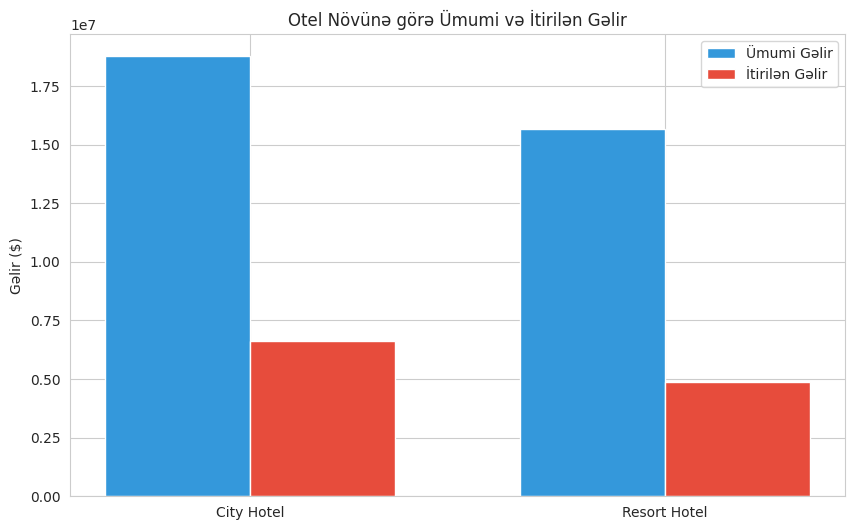

In [ ]:
# --- Otel Növünə görə Gəlir ---
revenue_by_hotel = df.groupby("hotel").agg(
    total_revenue=("revenue", "sum"),
    lost_revenue=("revenue", lambda x: x[df.loc[x.index, "is_canceled"] == 1].sum())
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(revenue_by_hotel))
width = 0.35
ax.bar(x - width/2, revenue_by_hotel["total_revenue"], width, label="Ümumi Gəlir", color="#3498db")
ax.bar(x + width/2, revenue_by_hotel["lost_revenue"], width, label="İtirilən Gəlir", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(revenue_by_hotel["hotel"])
ax.set_ylabel("Gəlir ($)")
ax.set_title("Otel Növünə görə Ümumi və İtirilən Gəlir")
ax.legend()
plt.show()

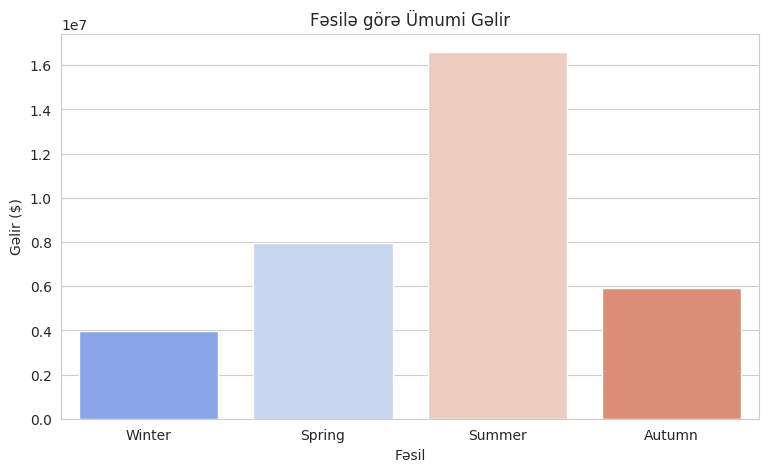

In [ ]:
# --- Fəsilə görə Gəlir ---
revenue_by_season = df.groupby("season", observed=True)["revenue"].sum().reindex(["Winter", "Spring", "Summer", "Autumn"])

plt.figure(figsize=(9, 5))
sns.barplot(x=revenue_by_season.index, y=revenue_by_season.values, palette="coolwarm")
plt.title("Fəsilə görə Ümumi Gəlir")
plt.ylabel("Gəlir ($)")
plt.xlabel("Fəsil")
plt.show()

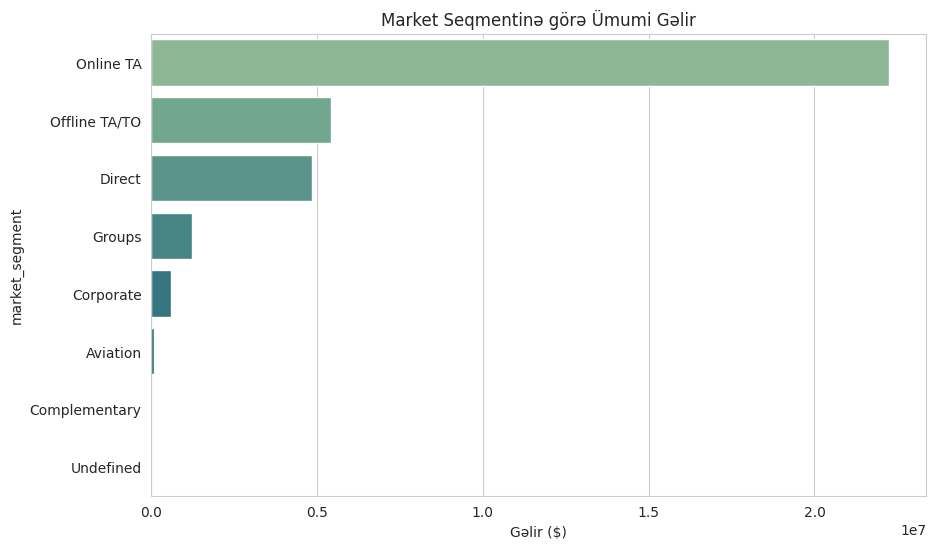

In [ ]:
# --- Market Seqmentinə görə Gəlir ---
revenue_by_segment = df.groupby("market_segment")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_segment.values, y=revenue_by_segment.index, palette="crest")
plt.title("Market Seqmentinə görə Ümumi Gəlir")
plt.xlabel("Gəlir ($)")
plt.show()

In [ ]:
# --- Recoverable Revenue (Qorunma Potensialı Olan Gəlir) ---
# Model tərəfindən "yüksək riskli" kimi işarələnmiş, amma hələ ləğv olunmamış rezervasiyaların gəliri —
# yəni düzgün tədbir görülərsə qorunma şansı olan gəlir
df_test_with_proba = X_test.copy()
df_test_with_proba["cancel_probability"] = y_proba_tuned
df_test_with_proba["actual_canceled"] = y_test.values
df_test_with_proba["revenue"] = df.loc[X_test.index, "revenue"].values

high_risk_not_canceled = df_test_with_proba[
    (df_test_with_proba["cancel_probability"] >= 0.5) & (df_test_with_proba["actual_canceled"] == 0)
]

recoverable_revenue = high_risk_not_canceled["revenue"].sum()
print(f"💡 Recoverable Revenue (qorunma potensialı olan gəlir): {recoverable_revenue:,.0f} $")
print(f"   Bu, {len(high_risk_not_canceled)} rezervasiyaya aiddir — bunlar 'yüksək riskli' "
      f"qiymətləndirilib, amma hələ ləğv edilməyib. Erkən müdaxilə ilə qorunma şansı var.")

💡 Recoverable Revenue (qorunma potensialı olan gəlir): 530,189 $
   Bu, 1059 rezervasiyaya aiddir — bunlar 'yüksək riskli' qiymətləndirilib, amma hələ ləğv edilməyib. Erkən müdaxilə ilə qorunma şansı var.


---
## 17 — What-If Simulator

İstifadəçi (otel meneceri) `lead_time`, `deposit_type`, `adr` və `special_requests` kimi dəyişənləri interaktiv şəkildə dəyişdirə bilər, model isə ləğv ehtimalını real vaxtda yenidən hesablayır. Bu, sadə bir proqnozdan **qərarvermə sisteminə** keçidi təmin edir.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Simulyasiya üçün baza olaraq test setindən bir "orta" rezervasiya seçirik
base_booking = X_test.iloc[0].copy()

def predict_cancellation_probability(booking_row):
    """Verilən bir rezervasiya sətri üçün ləğv ehtimalını qaytarır."""
    booking_df = pd.DataFrame([booking_row])
    proba = tuned_model.predict_proba(booking_df)[0, 1]
    return proba

# --- İnteraktiv widget-lər ---
lead_time_slider = widgets.IntSlider(value=int(base_booking["lead_time"]), min=0, max=500, step=1, description="Lead Time:")
adr_slider = widgets.FloatSlider(value=float(base_booking["adr"]), min=0, max=400, step=5, description="ADR ($):")
deposit_dropdown = widgets.Dropdown(options=["No Deposit", "Non Refund", "Refundable"], value="No Deposit", description="Depozit:")
requests_slider = widgets.IntSlider(value=int(base_booking["total_of_special_requests"]), min=0, max=5, step=1, description="Xüsusi tələb:")

output = widgets.Output()

def on_change(change):
    with output:
        clear_output(wait=True)
        # Baza rezervasiyanın üzərində seçilmiş dəyərləri yeniləyirik
        sim_booking = base_booking.copy()
        sim_booking["lead_time"] = lead_time_slider.value
        sim_booking["adr"] = adr_slider.value
        sim_booking["deposit_type"] = deposit_dropdown.value
        sim_booking["total_of_special_requests"] = requests_slider.value

        proba = predict_cancellation_probability(sim_booking)

        # Nəticəni rənglə vurğulayaraq göstəririk
        risk_color = "🔴" if proba >= 0.7 else "🟡" if proba >= 0.4 else "🟢"
        print(f"{risk_color} Ləğv Ehtimalı: {proba*100:.1f}%")

# Hər widget dəyişdikdə funksiyanı işə salırıq
for w in [lead_time_slider, adr_slider, deposit_dropdown, requests_slider]:
    w.observe(on_change, names="value")

display(widgets.VBox([lead_time_slider, adr_slider, deposit_dropdown, requests_slider, output]))
on_change(None)  # ilkin nəticəni göstərmək üçün

---
## 18 — Recommendation Engine

Model tərəfindən hesablanan risk faizinə əsasən avtomatik tövsiyələr yaradan sadə qayda-əsaslı (rule-based) sistem quraşdırırıq.

| Risk Səviyyəsi | Tövsiyə |
|---|---|
| Risk > 80% | Depozit tələb et (Request Deposit) |
| Risk 50–80% | Xatırlatma göndər (Send Reminder) |
| Risk < 50% | Heç bir tədbir lazım deyil (No Action Needed) |

📋 Tövsiyə Paylanması (Test Set üzrə):
recommendation
🟢 Tədbir Lazım Deyil — Aşağı Risk    13000
🟡 Xatırlatma Göndər — Orta Risk       2688
🔴 Depozit Tələb Et — Yüksək Risk      1636
Name: count, dtype: int64


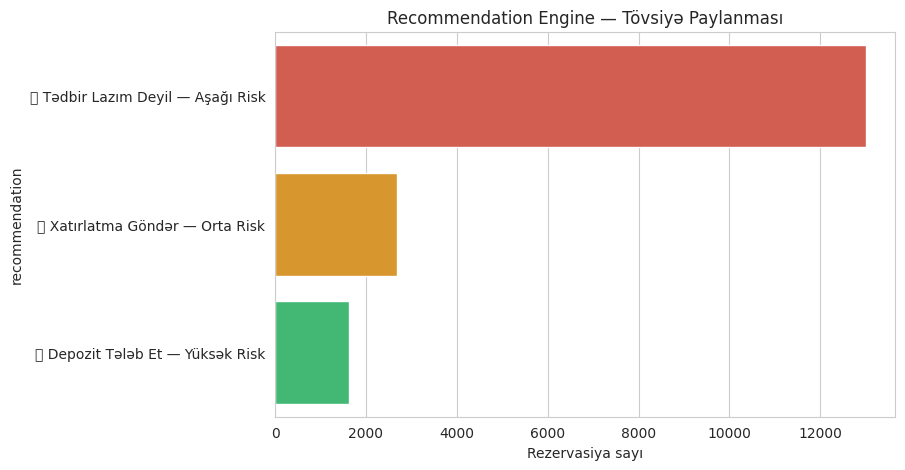

In [ ]:
def recommend_action(risk_probability: float) -> str:
    """
    Ləğv ehtimalına əsasən konkret biznes tövsiyəsi qaytarır.
    """
    if risk_probability > 0.80:
        return "🔴 Depozit Tələb Et — Yüksək Risk"
    elif risk_probability >= 0.50:
        return "🟡 Xatırlatma Göndər — Orta Risk"
    else:
        return "🟢 Tədbir Lazım Deyil — Aşağı Risk"

# Bütün test seti üçün tövsiyələri hesablayırıq
recommendations = pd.DataFrame({
    "cancel_probability": y_proba_tuned,
})
recommendations["recommendation"] = recommendations["cancel_probability"].apply(recommend_action)

# Tövsiyə kateqoriyalarının paylanmasına baxırıq
rec_counts = recommendations["recommendation"].value_counts()
print("📋 Tövsiyə Paylanması (Test Set üzrə):")
print(rec_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=rec_counts.values, y=rec_counts.index, palette=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Recommendation Engine — Tövsiyə Paylanması")
plt.xlabel("Rezervasiya sayı")
plt.show()

In [ ]:
# Nümunə olaraq ən yüksək riskli 10 rezervasiyanı və onlara aid tövsiyələri göstəririk
top_risky = recommendations.sort_values("cancel_probability", ascending=False).head(10).reset_index(drop=True)
top_risky.style.background_gradient(subset=["cancel_probability"], cmap="Reds")

,cancel_probability,recommendation
0,0.999992,🔴 Depozit Tələb Et — Yüksək Risk
1,0.999989,🔴 Depozit Tələb Et — Yüksək Risk
2,0.999987,🔴 Depozit Tələb Et — Yüksək Risk
3,0.999986,🔴 Depozit Tələb Et — Yüksək Risk
4,0.999984,🔴 Depozit Tələb Et — Yüksək Risk
5,0.999984,🔴 Depozit Tələb Et — Yüksək Risk
6,0.999984,🔴 Depozit Tələb Et — Yüksək Risk
7,0.999984,🔴 Depozit Tələb Et — Yüksək Risk
8,0.999982,🔴 Depozit Tələb Et — Yüksək Risk
9,0.999982,🔴 Depozit Tələb Et — Yüksək Risk


---
## 19 — Time Series Forecasting & Overbooking Simulation

- **19A — Time Series Forecasting:** Aylıq rezervasiya tələbini və ləğv nisbətini `ARIMA` ilə gələcək aylar üçün proqnozlaşdırırıq.
- **19B — Overbooking Monte Carlo Simulation:** Modelin proqnozlaşdırdığı ləğv ehtimallarından istifadə edərək optimal overbooking (artıq rezervasiya qəbulu) faizini tapırıq.

### 19A — Time Series Forecasting (ARIMA)

Dataset 2015–2017 illərini əhatə edir (26 ay). Aylıq ümumi rezervasiya sayını və ləğv nisbətini zaman seriyası kimi modelləşdirib son aylardakı real dəyərlərlə proqnozu müqayisə edəcəyik.

In [ ]:
# Statsmodels-i quraşdırırıq
!pip install -q statsmodels

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# --- Aylıq zaman seriyasını hazırlayırıq ---
# İl və ayı birləşdirərək düzgün xronoloji tarix (ilk gün) yaradırıq
month_num_map = {m: i+1 for i, m in enumerate(
    ["January", "February", "March", "April", "May", "June",
     "July", "August", "September", "October", "November", "December"]
)}
df["month_num"] = df["arrival_date_month"].astype(str).map(month_num_map)
df["year_month"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" + df["month_num"].astype(str) + "-01"
)

# Ayına görə qruplaşdırırıq: ümumi rezervasiya sayı və ləğv nisbəti
monthly_ts = df.groupby("year_month").agg(
    total_bookings=("is_canceled", "count"),
    cancellation_rate=("is_canceled", "mean")
).sort_index()

print(f"Zaman seriyasının uzunluğu: {len(monthly_ts)} ay")
monthly_ts.head()

Zaman seriyasının uzunluğu: 26 ay


,total_bookings,cancellation_rate
year_month,,
2015-07-01,1652,0.309927
2015-08-01,2428,0.235173
2015-09-01,2823,0.200142
2015-10-01,2660,0.165414
2015-11-01,1638,0.148352


In [ ]:
# --- Train/Test bölgüsü: son 6 ayı test üçün ayırırıq (zaman seriyasında SIRALAMA vacibdir!) ---
n_test = 6
train_ts = monthly_ts.iloc[:-n_test]
test_ts = monthly_ts.iloc[-n_test:]

print(f"Train: {len(train_ts)} ay | Test: {len(test_ts)} ay")

# --- ARIMA modelini 'total_bookings' seriyası üzərində qururuq ---
# ARIMA(p,d,q): p=avtoreqressiya dərəcəsi, d=fərqləmə dərəcəsi, q=hərəkətli orta dərəcəsi
# Qısa seriya olduğu üçün sadə (1,1,1) parametrini seçirik
arima_model = ARIMA(train_ts["total_bookings"], order=(1, 1, 1))
arima_fit = arima_model.fit()

# Test dövrü qədər irəli proqnoz veririk, 95% etibarlılıq intervalı ilə
forecast_result = arima_fit.get_forecast(steps=n_test)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

print(arima_fit.summary())

Train: 20 ay | Test: 6 ay
                               SARIMAX Results                                
Dep. Variable:         total_bookings   No. Observations:                   20
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -147.103
Date:                Sat, 18 Jul 2026   AIC                            300.206
Time:                        17:34:10   BIC                            303.039
Sample:                    07-01-2015   HQIC                           300.685
                         - 02-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8277      1.206      0.686      0.493      -1.536       3.191
ma.L1         -0.8762      1.032     -0.849      0.396      -2.898       1.146
sigma2      3.083e+05   1.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


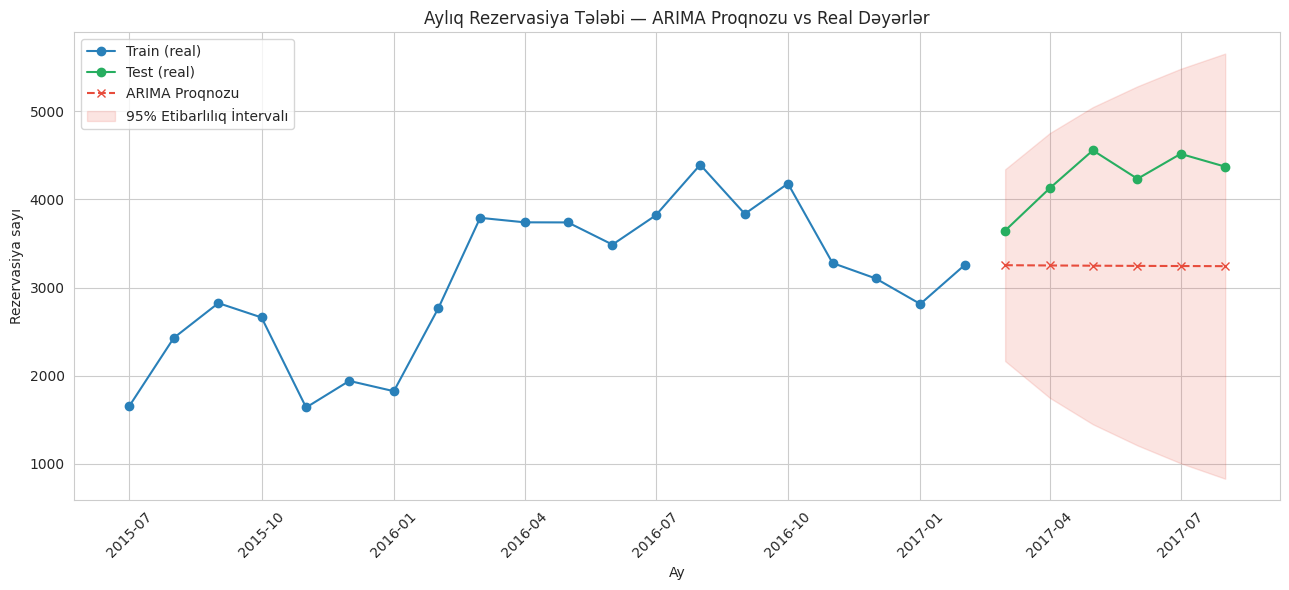


 Proqnoz Xətası — MAE: 995.0 rezervasiya, MAPE: 23.0%
 Qeyd: dataset yalnız 26 ay əhatə etdiyi üçün bu, illüstrativ bir nümunədir — real tətbiqdə daha uzun tarixçə (3-5+ il) daha etibarlı proqnoz verər.


In [ ]:
# --- Real və Proqnoz Dəyərlərini Vizuallaşdırırıq ---
plt.figure(figsize=(13, 6))
plt.plot(train_ts.index, train_ts["total_bookings"], label="Train (real)", color="#2980b9", marker="o")
plt.plot(test_ts.index, test_ts["total_bookings"], label="Test (real)", color="#27ae60", marker="o")
plt.plot(test_ts.index, forecast_mean, label="ARIMA Proqnozu", color="#e74c3c", linestyle="--", marker="x")
plt.fill_between(test_ts.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                  color="#e74c3c", alpha=0.15, label="95% Etibarlılıq İntervalı")
plt.title("Aylıq Rezervasiya Tələbi — ARIMA Proqnozu vs Real Dəyərlər")
plt.xlabel("Ay")
plt.ylabel("Rezervasiya sayı")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Proqnozun dəqiqliyini ölçürük (MAE — Mean Absolute Error)
mae = np.mean(np.abs(forecast_mean.values - test_ts["total_bookings"].values))
mape = np.mean(np.abs((forecast_mean.values - test_ts["total_bookings"].values) / test_ts["total_bookings"].values)) * 100
print(f"\n Proqnoz Xətası — MAE: {mae:.1f} rezervasiya, MAPE: {mape:.1f}%")
print(" Qeyd: dataset yalnız 26 ay əhatə etdiyi üçün bu, illüstrativ bir nümunədir — "
      "real tətbiqdə daha uzun tarixçə (3-5+ il) daha etibarlı proqnoz verər.")

In [ ]:
# --- Gələcək 3 Ay üçün Proqnoz (dataset bitdikdən sonrakı dövr) ---
# Bu dəfə BÜTÜN mövcud datadan (train+test) istifadə edərək modeli yenidən öyrədirik
full_arima = ARIMA(monthly_ts["total_bookings"], order=(1, 1, 1)).fit()
future_forecast = full_arima.get_forecast(steps=3)

future_dates = pd.date_range(start=monthly_ts.index[-1] + pd.DateOffset(months=1), periods=3, freq="MS")
future_df = pd.DataFrame({
    "Proqnozlaşdırılan Rezervasiya Sayı": future_forecast.predicted_mean.values
}, index=future_dates)

print("🔮 Növbəti 3 Ay üçün Tələb Proqnozu:")
future_df.round(0)

🔮 Növbəti 3 Ay üçün Tələb Proqnozu:


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Proqnozlaşdırılan Rezervasiya Sayı
2017-09-01,4357.0
2017-10-01,4354.0
2017-11-01,4353.0


### 19B — Overbooking Monte Carlo Simulation

Otellər boş qalan otaqlardan itki çəkməmək üçün adətən **overbooking** (otaq tutumundan bir qədər çox rezervasiya qəbul etmək) strategiyası tətbiq edir — çünki bəzi qonaqların gəlməyəcəyi (ləğv) əvvəlcədən bilinir.

Burada Mərhələ 9-14-də öyrətdiyimiz modelin **proqnozlaşdırdığı ləğv ehtimallarından** istifadə edərək, min itki verən optimal overbooking faizini Monte Carlo simulyasiyası ilə tapırıq.

In [ ]:
# --- Simulyasiya üçün parametrləri təyin edirik ---
np.random.seed(42)

room_capacity = 100                                    # otelin gecəlik otaq tutumu (fərziyyə)
avg_adr = df["adr"].mean()                              # otaq başına orta gündəlik gəlir
walk_cost_per_guest = avg_adr * 3                        # 'walked' qonaq başına itki (kompensasiya + reputasiya, fərziyyə: 3×ADR)
empty_room_cost = avg_adr                                 # boş qalan otaq başına itirilən gəlir

n_simulations = 2000                                       # hər overbooking səviyyəsi üçün simulyasiya sayı
overbooking_levels = np.arange(0, 0.31, 0.02)             # 0%-dan 30%-ə qədər, 2% addımla

# Modelin test setindəki bütün rezervasiyalar üçün proqnozlaşdırdığı ləğv ehtimalları —
# real ləğv davranışının "nümunə paylanması" kimi istifadə olunur
cancel_prob_pool = y_proba_tuned

print(f"Otaq tutumu: {room_capacity}")
print(f"Orta ADR: ${avg_adr:.2f}")
print(f"Walk cost (qonaq başına): ${walk_cost_per_guest:.2f}")
print(f"Boş otaq itkisi (otaq başına): ${empty_room_cost:.2f}")

Otaq tutumu: 100
Orta ADR: $107.25
Walk cost (qonaq başına): $321.76
Boş otaq itkisi (otaq başına): $107.25


In [ ]:
def simulate_overbooking(overbooking_pct, capacity, cancel_probs, n_sim=2000):
    """
    Verilən overbooking faizi üçün Monte Carlo simulyasiyası aparır və
    orta gözlənilən itkini (walk cost + empty room cost) qaytarır.
    """
    accepted_bookings = int(capacity * (1 + overbooking_pct))
    total_costs = []

    for _ in range(n_sim):
        # Qəbul edilən hər rezervasiya üçün modelin ehtimal fondundan təsadüfi seçim edirik
        sampled_probs = np.random.choice(cancel_probs, size=accepted_bookings, replace=True)
        # Hər rezervasiya üçün, öz ehtimalına əsasən ləğv olub-olmadığını simulyasiya edirik (Bernoulli)
        cancellations = np.random.binomial(1, sampled_probs)
        arrivals = accepted_bookings - cancellations.sum()

        if arrivals > capacity:
            # Otaqdan çox qonaq gəlib — 'walk' etmək lazımdır (bahalı itki)
            cost = (arrivals - capacity) * walk_cost_per_guest
        else:
            # Otaqlar boş qalıb — itirilmiş gəlir
            cost = (capacity - arrivals) * empty_room_cost

        total_costs.append(cost)

    return np.mean(total_costs), np.std(total_costs)

# --- Hər overbooking səviyyəsi üçün simulyasiyanı işə salırıq ---
results = []
for level in overbooking_levels:
    mean_cost, std_cost = simulate_overbooking(level, room_capacity, cancel_prob_pool, n_simulations)
    results.append({"overbooking_pct": level * 100, "avg_cost": mean_cost, "std_cost": std_cost})

sim_results_df = pd.DataFrame(results)
optimal_level = sim_results_df.loc[sim_results_df["avg_cost"].idxmin()]

print(f"🏆 Optimal Overbooking Faizi: {optimal_level['overbooking_pct']:.0f}%")
print(f"   Bu səviyyədə gözlənilən orta gündəlik itki: ${optimal_level['avg_cost']:.2f}")

🏆 Optimal Overbooking Faizi: 30%
   Bu səviyyədə gözlənilən orta gündəlik itki: $743.21


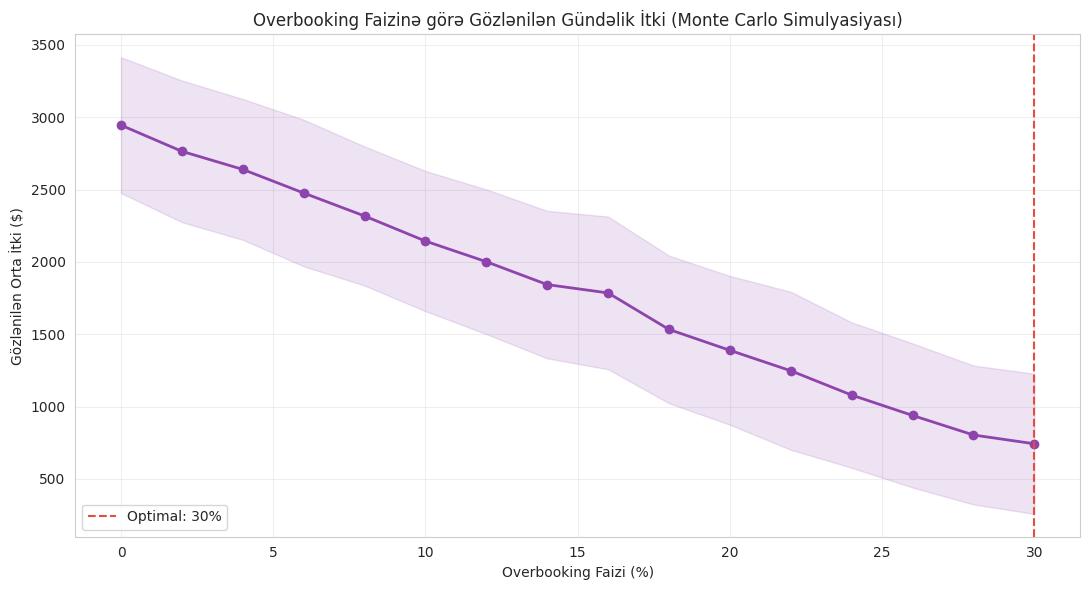

 Sıfır overbooking-də itki əsasən boş otaqlardan, yüksək overbooking-də isə 'walk' etmə xərclərindən qaynaqlanır. Optimal nöqtə bu ikisinin balansıdır.


In [ ]:
# --- Overbooking Faizinə görə Gözlənilən İtki Əyrisi ---
plt.figure(figsize=(11, 6))
plt.plot(sim_results_df["overbooking_pct"], sim_results_df["avg_cost"],
          marker="o", color="#8e44ad", linewidth=2)
plt.fill_between(
    sim_results_df["overbooking_pct"],
    sim_results_df["avg_cost"] - sim_results_df["std_cost"],
    sim_results_df["avg_cost"] + sim_results_df["std_cost"],
    alpha=0.15, color="#8e44ad"
)
plt.axvline(optimal_level["overbooking_pct"], color="#e74c3c", linestyle="--",
            label=f"Optimal: {optimal_level['overbooking_pct']:.0f}%")
plt.title("Overbooking Faizinə görə Gözlənilən Gündəlik İtki (Monte Carlo Simulyasiyası)")
plt.xlabel("Overbooking Faizi (%)")
plt.ylabel("Gözlənilən Orta İtki ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(" Sıfır overbooking-də itki əsasən boş otaqlardan, yüksək overbooking-də isə "
      "'walk' etmə xərclərindən qaynaqlanır. Optimal nöqtə bu ikisinin balansıdır.")

---
## 20 — Dashboard

Dashboard hissəsi ayrıca bir **Streamlit tətbiqi** kimi hazırlanıb

Dashboard aşağıdakı tablardan ibarətdir:

| Tab | Məzmun |
|---|---|
| **Overview** | Ümumi KPI-lar: rezervasiya sayı, ləğv nisbəti, gəlir |
| **Cancellation Insights** | Ləğv nisbətinin seqment/depozit/lead-time üzrə təhlili, korrelyasiya |
| **Revenue Analytics** | Gəlir itkisi, otel/fəsil/seqment üzrə bölgü |
| **Countries** | Dünya xəritəsi, ölkə üzrə rezervasiya və ləğv nisbəti |
| **What-If Simulator** | İnteraktiv risk kalkulyatoru və avtomatik tövsiyə |

Tətbiqi işə salmaq üçün terminalda:

```bash
streamlit run streamlit_dashboard.py
```


---
## Son Arxitektura

```
Hotel Booking Dataset
       │
       ▼
   Cleaning
       │
       ▼
     EDA
       │
       ▼
Feature Engineering
       │
       ▼
   Pipeline (ColumnTransformer)
       │
       ▼
   ML Models (LogReg / RF / XGBoost)
       │
       ▼
 Model Comparison
       │
       ▼
Hyperparameter Tuning (RandomizedSearchCV)
       │
       ▼
Cross Validation (5-Fold)
       │
       ▼
Threshold Optimization
       │
       ▼
   SHAP (Explainable AI)
       │
       ▼
 Revenue Analytics
       │
       ▼
 What-If Simulator
       │
       ▼
Recommendation Engine
       │
       ▼
Time Series Forecasting (ARIMA)
       │
       ▼
Overbooking Monte Carlo Simulation
       │
       ▼
   Dashboard
```


---
## ✅ Yekun Nəticə və Business Impact

Bu bölmədə bütün layihənin verdiyi nəticələri qısaca ümumiləşdiririk.

In [ ]:
print("=" * 60)
print("📌 STAYPREDICT — LAYİHƏ XÜLASƏSİ")
print("=" * 60)
print(f"\n🔢 Analiz edilən rezervasiya sayı:      {df.shape[0]:,}")
print(f"📉 Ümumi ləğv nisbəti:                  {df['is_canceled'].mean()*100:.2f}%")
print(f"🏆 Qalib model:                          {best_model_name} (tuning sonrası XGBoost)")
print(f"🎯 Model ROC-AUC (test set):             {roc_auc_score(y_test, y_proba_tuned):.4f}")
print(f"🎯 Model Recall (optimal threshold ilə): {recall_score(y_test, y_pred_optimal):.4f}")
print(f"💰 Ümumi potensial gəlir:                {total_revenue:,.0f} $")
print(f"💸 Ləğvlər səbəbiylə illik itki:         {lost_revenue:,.0f} $")
print(f"💡 Erkən müdaxilə ilə qorunma potensialı: {recoverable_revenue:,.0f} $")
print("\n" + "=" * 60)
print("Bu layihə: proqnozlaşdırma + izah edilə bilənlik + biznes dəyəri")
print("üçlüyünü bir araya gətirən tam funksional bir sistemdir.")
print("=" * 60)

📌 STAYPREDICT — LAYİHƏ XÜLASƏSİ

🔢 Analiz edilən rezervasiya sayı:      86,620
📉 Ümumi ləğv nisbəti:                  27.69%
🏆 Qalib model:                          XGBoost (tuning sonrası XGBoost)
🎯 Model ROC-AUC (test set):             0.9126
🎯 Model Recall (optimal threshold ilə): 0.7603
💰 Ümumi potensial gəlir:                34,448,497 $
💸 Ləğvlər səbəbiylə illik itki:         11,483,803 $
💡 Erkən müdaxilə ilə qorunma potensialı: 530,189 $

Bu layihə: proqnozlaşdırma + izah edilə bilənlik + biznes dəyəri
üçlüyünü bir araya gətirən tam funksional bir sistemdir.




*StayPredict — AI-Powered Hotel Revenue and Cancellation Management System*
